# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

import os # library to use for using the files in my folder

# location for my folder consisting of the files 
os.chdir(r'C:\Users\kanua\Downloads\NYC_Taxi_EDA')


In [2]:
# Import all the libraries we need for this project
import numpy as np               # library for maths calcualtions
import pandas as pd              # library for data table
import matplotlib.pyplot as plt  # library for drawing charts
import seaborn as sns            # library to make the charts good and proper

In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2



# recommened versions used for numpy, pandas,matplotlib and seasborn and verification
print('numpy version:', np.__version__)
print('pandas version:', pd.__version__)
print('matplotlib version:', plt.matplotlib.__version__)
print('seaborn version:', sns.__version__)

numpy version: 2.3.5
pandas version: 2.3.3
matplotlib version: 3.10.6
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file

#loading the january file
df = pd.read_parquet('data/2023-1.parquet')

# seeing the contents of the file ie rows and columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [5]:
# We will sample data in the next cell
# It is recommended to not load all files at once to avoid memory overload

In [6]:
# This cell was for Google Colab - not needed for Jupyter on your PC
# We will use a local folder path instead

In [7]:
# sample 5% data from each hour and combine all monthly files


# folder name for all the parquet files in my pc is data
data_folder = 'data'

# gettting all the parquet files and storing them in the list in order
file_list = [
    '2023-1.parquet',
    '2023-2.parquet',
    '2023-3.parquet',
    '2023-4.parquet',
    '2023-5.parquet',
    '2023-6.parquet',
    '2023-7.parquet',
    '2023-8.parquet',
    '2023-9.parquet',
    '2023-10.parquet',
    '2023-11.parquet',
    '2023-12.parquet'
]

# initialise an empty dataframe
df = pd.DataFrame()

# taking the small percentage as 5%
sample_fraction = 0.05

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # this builds the full path to the file in my pc
        file_path = os.path.join(data_folder, file_name)
        print(f'Reading file: {file_name}...')

        # reads the parquet file into a temporary dataframe
        month_df = pd.read_parquet(file_path)

        # extracting the date and hour from the pickup datetime column
        month_df['pickup_date'] = month_df['tpep_pickup_datetime'].dt.date
        month_df['pickup_hour'] = month_df['tpep_pickup_datetime'].dt.hour

        # creating empty dataframe to store sampled data for this month
        sampled_data = pd.DataFrame()

        # unique dates in this month stored in a list
        unique_dates = month_df['pickup_date'].unique()

        # looping through each date
        for date in unique_dates:
            # filtering data for a specific date
            day_data = month_df[month_df['pickup_date'] == date]

            # loop through each hour (0 to 23)
            for hour in range(24):
                # filtering data for this specific hour
                hour_data = day_data[day_data['pickup_hour'] == hour]

                # only sample if there is data for this hour
                if len(hour_data) > 0:
                    # taking 5% random sample from this hour's data
                    sample = hour_data.sample(frac=sample_fraction, random_state=42)
                    # adding this sample to our monthly sampled data
                    sampled_data = pd.concat([sampled_data, sample])

        # adding the monthly sampled data to the main dataframe
        df = pd.concat([df, sampled_data])
        print(f'  Done! Sampled {len(sampled_data)} rows from {file_name}')

    except Exception as e:
        print(f'Error reading file {file_name}: {e}')

print(f'\nTotal rows in combined dataset: {len(df)}')
print(f'Total columns: {len(df.columns)}')

Reading file: 2023-1.parquet...
  Done! Sampled 152087 rows from 2023-1.parquet
Reading file: 2023-2.parquet...
  Done! Sampled 168696 rows from 2023-2.parquet
Reading file: 2023-3.parquet...
  Done! Sampled 163786 rows from 2023-3.parquet
Reading file: 2023-4.parquet...
  Done! Sampled 139641 rows from 2023-4.parquet
Reading file: 2023-5.parquet...
  Done! Sampled 144458 rows from 2023-5.parquet
Reading file: 2023-6.parquet...
  Done! Sampled 162910 rows from 2023-6.parquet
Reading file: 2023-7.parquet...
  Done! Sampled 174068 rows from 2023-7.parquet
Reading file: 2023-8.parquet...
  Done! Sampled 143782 rows from 2023-8.parquet
Reading file: 2023-9.parquet...
  Done! Sampled 140875 rows from 2023-9.parquet
Reading file: 2023-10.parquet...
  Done! Sampled 174255 rows from 2023-10.parquet
Reading file: 2023-11.parquet...
  Done! Sampled 165133 rows from 2023-11.parquet
Reading file: 2023-12.parquet...
  Done! Sampled 166709 rows from 2023-12.parquet

Total rows in combined dataset: 1

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [8]:
# saving the 12 combined files to a new parquet file so the above cell block need not be executed everytime
df.to_parquet('nyc_taxi_2023_combined_sampled.parquet')
print('Saved! File: nyc_taxi_2023_combined_sampled.parquet')
print('Total rows saved:', len(df))

Saved! File: nyc_taxi_2023_combined_sampled.parquet
Total rows saved: 1896400


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [9]:
# loading  the combined saved file
df = pd.read_parquet('nyc_taxi_2023_combined_sampled.parquet')
print('Data loaded successfully!')
print('Number of rows:', len(df))
print('Number of columns:', len(df.columns))

Data loaded successfully!
Number of rows: 1896400
Number of columns: 22


In [10]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
428,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
1113,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
819,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
3192,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN
2995263,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,...,0.5,5.93,0.0,1.0,35.57,NaN,NaN,2023-01-01,0,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1896400 entries, 428 to 3196303
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            fl

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [12]:
# to make sure that the index starts from 0
df = df.reset_index(drop=True)

# removing columns store_and_fwd_flag and pickup_date as these arent required
columns_to_drop = ['store_and_fwd_flag', 'pickup_date']

# checking to see if the columns exist in the database and then removing them
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=columns_to_drop)


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [13]:
# theres two airport_fee columns which needs to be combined

# colunms present check 
airport_columns = [col for col in df.columns if 'airport' in col.lower()]

# the nan values of airport_fee are assigned from the other airport_fee
if 'airport_fee' in df.columns and 'Airport_fee' in df.columns:
    df['airport_fee'] = df['airport_fee'].fillna(df['Airport_fee'])
    # after the values have been assigned the ahe column is removed
    df = df.drop(columns=['Airport_fee'])

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [14]:
# checking for any negative fare amount
negative_fares = df[df['fare_amount'] < 0]

# if any negativc fares exist, its being counted and printed
print('Number of rows with negative fare_amount:', len(negative_fares))
negative_fares.head(10)

Number of rows with negative fare_amount: 0


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour


Did you notice something different in the `RatecodeID` column for above records?

In [15]:
# analysing the ratecodeid for trips with negative fairs
print('RatecodeID values for negative fare trips:')
print(df[df['fare_amount'] < 0]['RatecodeID'].value_counts())

RatecodeID values for negative fare trips:
Series([], Name: count, dtype: int64)


In [16]:
# finding all the columns with negative values
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print('Columns with negative values:')
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f'  {col}: {neg_count} negative values')

Columns with negative values:
  extra: 3 negative values
  mta_tax: 73 negative values
  improvement_surcharge: 78 negative values
  total_amount: 78 negative values
  congestion_surcharge: 56 negative values
  airport_fee: 15 negative values


In [17]:
# fixing the negative values by taking their absolute value 
# money amounts should never be negative

# List of money columns that should never be negative
money_columns = ['fare_amount', 'extra', 'mta_tax', 'tip_amount',
                 'tolls_amount', 'improvement_surcharge', 'total_amount',
                 'congestion_surcharge', 'airport_fee']

# coverting negative to positive for each money column
for col in money_columns:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            df[col] = df[col].abs()  # abs() makes negative numbers positive
            print(f'Fixed {neg_count} negative values in {col}')

print('\nAll negative monetary values have been fixed!')

Fixed 3 negative values in extra
Fixed 73 negative values in mta_tax
Fixed 78 negative values in improvement_surcharge
Fixed 78 negative values in total_amount
Fixed 56 negative values in congestion_surcharge
Fixed 15 negative values in airport_fee

All negative monetary values have been fixed!


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [18]:
# finding out how many rows have missing values and counting them
total_rows = len(df)
missing_count = df.isnull().sum()
missing_percent = (missing_count / total_rows) * 100 # percentage of rows missing a value

# creating a summary table with count and percentage as 2 colunms
summary_table_for_missing_values = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

# priniing only the colunms with missing values
summary_table_for_missing_values = summary_table_for_missing_values[summary_table_for_missing_values['Missing Count'] > 0]
print('Columns with missing values:')
print(summary_table_for_missing_values)

Columns with missing values:
                      Missing Count  Missing Percent (%)
passenger_count               64874                 3.42
RatecodeID                    64874                 3.42
congestion_surcharge          64874                 3.42
airport_fee                   64874                 3.42


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [19]:
# passenger count missing check
print('Rows with missing passenger_count:', df['passenger_count'].isnull().sum())

# using median tofill the missing passenger count as its a whole number
median_of_passengers = df['passenger_count'].median()
print(f'Median passenger count: {median_of_passengers}')
df['passenger_count'] = df['passenger_count'].fillna(median_of_passengers)

# couting rows to to see where passenger count is zero as it should atleast be 1
zero_passengers = (df['passenger_count'] == 0).sum()
print(f'\nRows with zero passengers: {zero_passengers}')
df['passenger_count'] = df['passenger_count'].replace(0, median_of_passengers) # median value put for zero values

print('passenger_count missing values after fix:', df['passenger_count'].isnull().sum())

Rows with missing passenger_count: 64874
Median passenger count: 1.0

Rows with zero passengers: 29681
passenger_count missing values after fix: 0


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [20]:
# counting how many rows have missing ratecodeid and how many times each ratecodeid appears
print('Missing RatecodeID values:', df['RatecodeID'].isnull().sum())
print('RatecodeID value counts:')
print(df['RatecodeID'].value_counts())

# filling missing ratecodeid with 1 (Standard rate) - the most common rate type
df['RatecodeID'] = df['RatecodeID'].fillna(1.0)
print('\nMissing RatecodeID after fix:', df['RatecodeID'].isnull().sum())

Missing RatecodeID values: 64874
RatecodeID value counts:
RatecodeID
1.0     1729259
2.0       71670
99.0      10472
5.0       10275
3.0        6124
4.0        3723
6.0           3
Name: count, dtype: int64

Missing RatecodeID after fix: 0


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [21]:
# handling null values in congestion_surcharge
print('Missing congestion_surcharge values:', df['congestion_surcharge'].isnull().sum())

# filling null values with zero which will show that no surcharge was applied
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)

print('Missing congestion_surcharge after fix:', df['congestion_surcharge'].isnull().sum())

Missing congestion_surcharge values: 64874
Missing congestion_surcharge after fix: 0


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [22]:
# checking for any mising values in the coiumns
print('Remaining missing values:')
print(df.isnull().sum())

# making airport_fee as 0 for the missing values
if df['airport_fee'].isnull().sum() > 0:
    df['airport_fee'] = df['airport_fee'].fillna(0)
    print('Fixed missing airport_fee values')

print('\nAll missing values handled!')
print('Final missing value count:')
print(df.isnull().sum())

Remaining missing values:
VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count              0
trip_distance                0
RatecodeID                   0
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge         0
airport_fee              64874
pickup_hour                  0
dtype: int64
Fixed missing airport_fee values

All missing values handled!
Final missing value count:
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra        

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [23]:
# summary of all numeric columns
df.describe().round(2) # rounding to 2 decimal places for readeability

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour
count,1896400.00,1896400,1896400,1896400.00,1896400.00,1896400.00,1896400.00,1896400.00,1896400.00,1896400.00,1896400.00,1896400.00,1896400.00,1896400.00,1896400.00,1896400.00,1896400.00,1896400.00,1896400.00
mean,1.73,2023-07-02 19:59:52.930795,2023-07-02 20:17:18.919562,1.37,3.86,1.61,165.28,164.05,1.16,19.92,1.59,0.50,3.55,0.60,1.00,28.98,2.23,0.14,14.27
min,1.00,2022-12-31 23:51:30,2022-12-31 23:56:06,1.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,2023-04-02 16:10:08.750000,2023-04-02 16:27:43.500000,1.00,1.05,1.00,132.00,114.00,1.00,9.30,0.00,0.50,1.00,0.00,1.00,15.96,2.50,0.00,11.00
50%,2.00,2023-06-27 15:44:22.500000,2023-06-27 16:01:15,1.00,1.79,1.00,162.00,162.00,1.00,13.50,1.00,0.50,2.85,0.00,1.00,21.00,2.50,0.00,15.00
75%,2.00,2023-10-06 19:37:45,2023-10-06 19:53:39,1.00,3.40,1.00,234.00,234.00,1.00,21.90,2.50,0.50,4.42,0.00,1.00,30.94,2.50,0.00,19.00
max,6.00,2023-12-31 23:57:51,2024-01-01 20:50:55,9.00,126360.46,99.00,265.00,265.00,4.00,143163.45,20.80,4.00,223.08,143.00,1.00,143167.45,2.50,1.75,23.00
std,0.45,NaN,NaN,0.86,129.41,7.27,64.00,69.80,0.51,105.54,1.83,0.05,4.05,2.19,0.03,106.42,0.78,0.46,5.81


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [24]:
# saving row to comparisons
before = len(df)

# keeping rows where passenger count is <=6
df = df[df['passenger_count'] <= 6]
after = len(df) #saves the rows after above condition is met
print(f'Removed {before - after} rows with passenger_count > 6')
print(f'Remaining rows: {after}')

Removed 21 rows with passenger_count > 6
Remaining rows: 1896379


In [25]:
# Continuing with outlier handling

# removing trips with distance >=250 miles
df = df[df['trip_distance'] <= 250]

# here the trips wwhere both the distance and fare are 0 but zones are different are removed
# because the trip should cover some distance if zones are different
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) &
           (df['PULocationID'] != df['DOLocationID']))]

# deleting payment type=0 as thats not valid as per the data set
df = df[df['payment_type'] != 0]

In [26]:
# standardising

# passenger_count and vendorid cannot be decimal type so converting them to integer
df['passenger_count'] = df['passenger_count'].astype(int)
df['VendorID'] = df['VendorID'].astype(int)
df['payment_type'] = df['payment_type'].astype(int)
df['RatecodeID'] = df['RatecodeID'].astype(int)

# making sure datetime columns are in datetime format for calculations
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# creating these time_based columns for analysis 
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour          #hour 
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()     #dayname
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month        #monthno
df['pickup_month_name'] = df['tpep_pickup_datetime'].dt.month_name()  #monthname

# calculating trip duration in minutes
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# removing trips with negative or 0 duration
df = df[df['trip_duration'] > 0]

print('Data types standardised!')
print(df.dtypes)

Data types standardised!
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
pickup_hour                       int32
pickup_day                       object
pickup_month                      int32
pickup_month_name                object
trip_duration                   float64
dtype: object


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [27]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'pickup_hour',
 'pickup_day',
 'pickup_month',
 'pickup_month_name',
 'trip_duration']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`:Categorical
* `tpep_dropoff_datetime`:Categorical
* `passenger_count`:Numerical
* `trip_distance`:Numerical
* `RatecodeID`:Categorical
* `PULocationID`:Categorical
* `DOLocationID`:Categorical
* `payment_type`:Categorical
* `pickup_hour`:Categorical
* `trip_duration`:Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`-numerical
* `extra`-numerical
* `mta_tax`-numerical
* `tip_amount`-numerical
* `tolls_amount`-numerical
* `improvement_surcharge`-numerical
* `total_amount`-numerical
* `congestion_surcharge`-numerical
* `airport_fee`-numerical

# reason as they are amount where mathmatical operations can be done

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

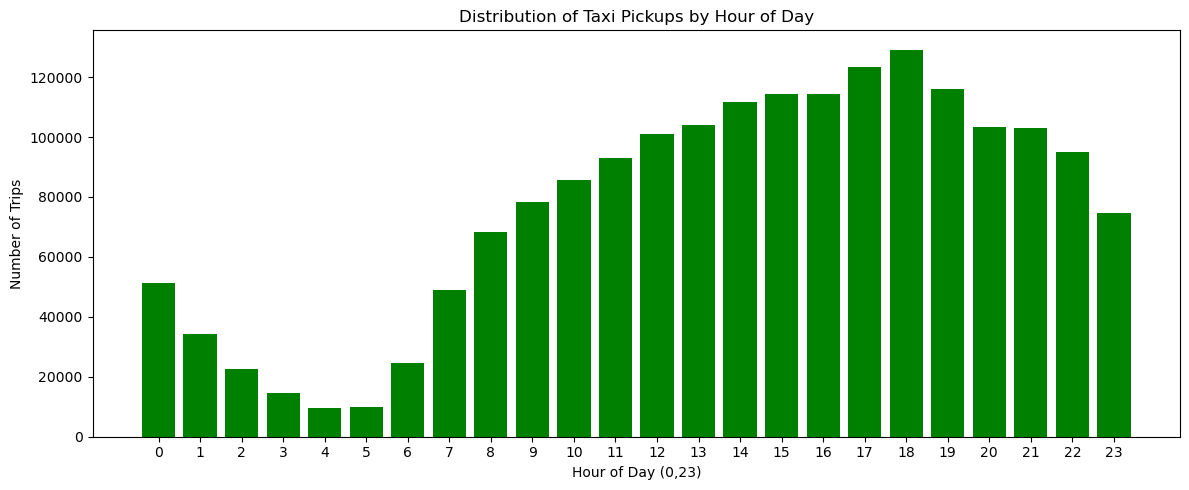

In [28]:
# grouping all trips by hour and then counting it hourwise
hourly_pickups = df.groupby('pickup_hour').size().reset_index(name='trip_count')

# plotting a bar chart
plt.figure(figsize=(12, 5)) #creats an empty chart

# adding all the details in the chart 
plt.bar(hourly_pickups['pickup_hour'], hourly_pickups['trip_count'], color='green')
plt.title('Distribution of Taxi Pickups by Hour of Day')
plt.xlabel('Hour of Day (0,23)')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

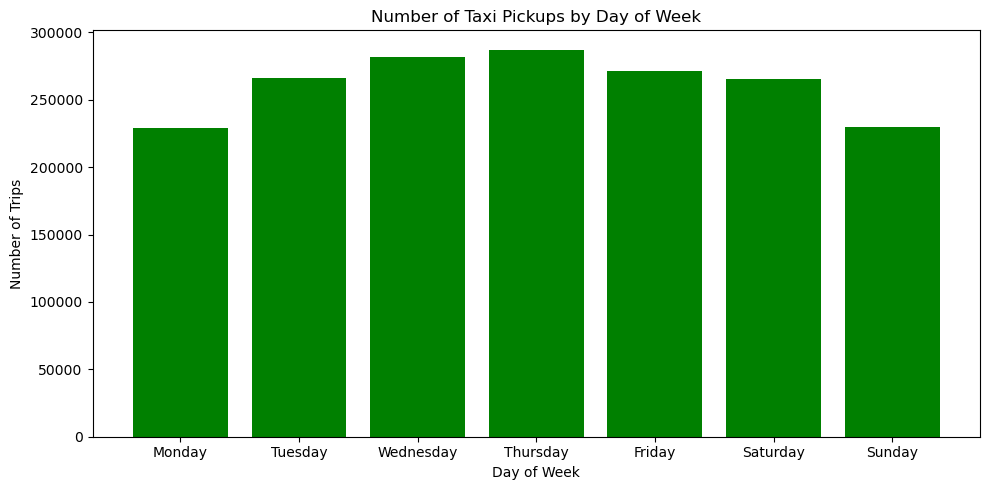

In [29]:
# counting pickups for each day of the week

# listing the days in correct order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# groups all trips by day after which counting how many happened each day
daily_pickups = df.groupby('pickup_day').size().reset_index(name='trip_count')

# monday to sunday order
daily_pickups['pickup_day'] = pd.Categorical(daily_pickups['pickup_day'], categories=day_order, ordered=True)
daily_pickups = daily_pickups.sort_values('pickup_day')

# plotting the bar graph
plt.figure(figsize=(10, 5))
plt.bar(daily_pickups['pickup_day'], daily_pickups['trip_count'], color='green')
plt.title('Number of Taxi Pickups by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.show()

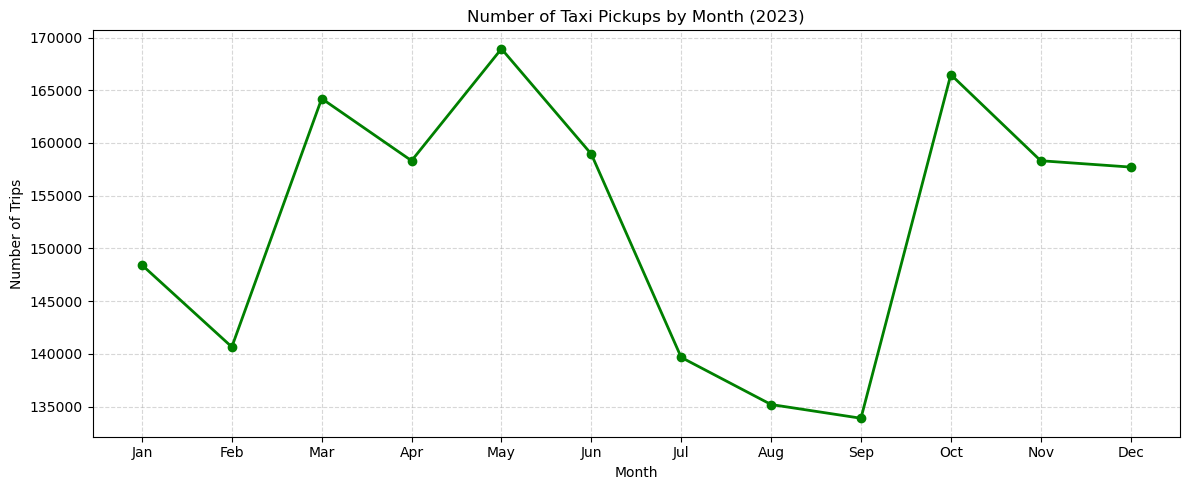

In [30]:
# grouping by month and then counting the monthly trips
monthly_pickups = df.groupby('pickup_month').size().reset_index(name='trip_count')

# plotting month names in the graph
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# plotting the graph
plt.figure(figsize=(12, 5))
plt.plot(monthly_pickups['pickup_month'], monthly_pickups['trip_count'], marker='o', color='green', linewidth=2)
plt.title('Number of Taxi Pickups by Month (2023)')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.xticks(range(1, 13), month_names)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [31]:
# looking at fare_amount, tip_amount, total_amount, trip_distance

# creating list of the above said columns
financial_cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

# looping through each colmns 
for col in financial_cols:
    zero_count = (df[col] <= 0).sum() #counting any zero or negative values
    print(f'{col}: min={df[col].min():.2f}, max={df[col].max():.2f}, zeros/negatives={zero_count}')

fare_amount: min=0.00, max=143163.45, zeros/negatives=572
tip_amount: min=0.00, max=223.08, zeros/negatives=409667
total_amount: min=0.00, max=143167.45, zeros/negatives=254
trip_distance: min=0.00, max=204.86, zeros/negatives=22366


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [32]:
# creating a clean copy of the dataframe with zero or negative values removed from above given columns
df_clean = df[(df['fare_amount'] > 0) & (df['total_amount'] > 0)].copy()

# showing the changes
print(f'Original rows: {len(df)}')
print(f'Clean rows (after removing zero fares): {len(df_clean)}')
print(f'Rows removed: {len(df) - len(df_clean)}')

Original rows: 1830740
Clean rows (after removing zero fares): 1830168
Rows removed: 572


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

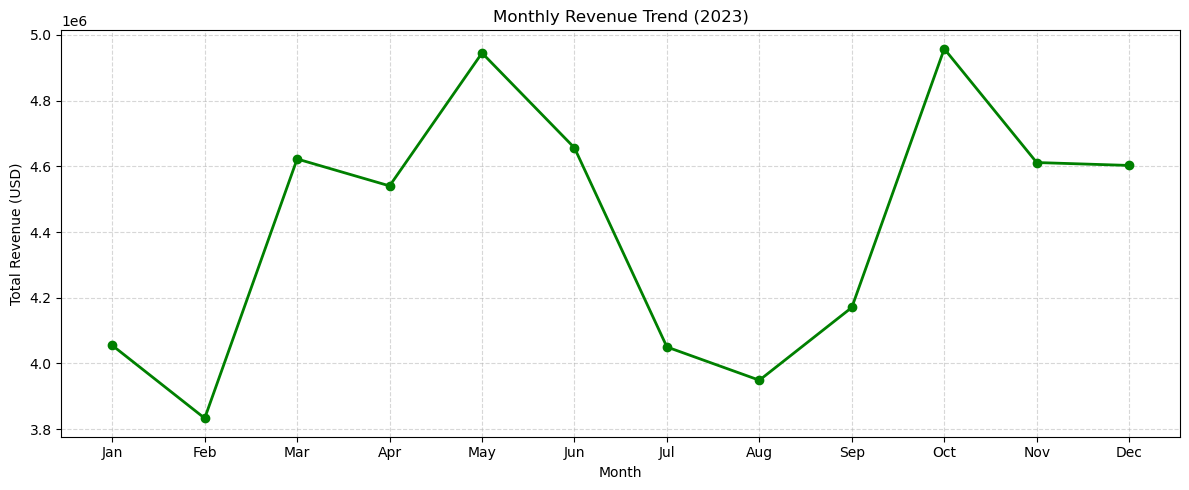

    month  total_revenue
0       1     4055112.28
1       2     3833376.56
2       3     4622318.81
3       4     4540408.47
4       5     4944849.25
5       6     4656140.21
6       7     4050211.27
7       8     3949080.80
8       9     4170482.88
9      10     4957562.43
10     11     4611506.65
11     12     4602649.15


In [33]:
# grouping by month and then calculating the total amount by each month
monthly_revenue = df_clean.groupby('pickup_month')['total_amount'].sum().reset_index()
monthly_revenue.columns = ['month', 'total_revenue'] #renaming for readability

# making the month names short for plotting in graph
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# plotting the graph
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['month'], monthly_revenue['total_revenue'], marker='o', color='green', linewidth=2)
plt.title('Monthly Revenue Trend (2023)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.xticks(range(1, 13), month_names)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(monthly_revenue)

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

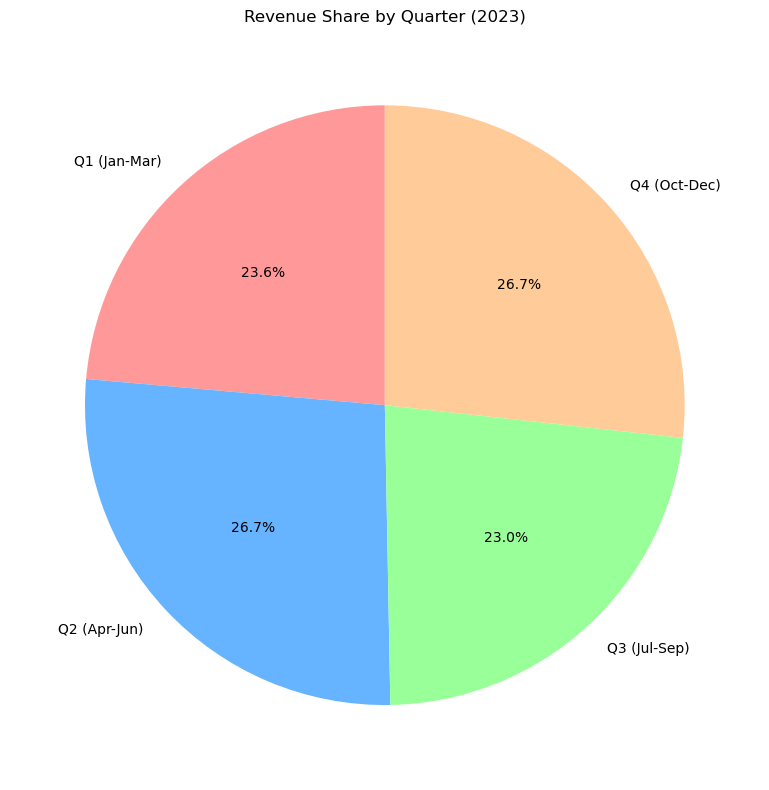

Revenue by Quarter:
quarter
Q1 (Jan-Mar)    12510807.65
Q2 (Apr-Jun)    14141397.93
Q3 (Jul-Sep)    12169774.95
Q4 (Oct-Dec)    14171718.23
Name: total_amount, dtype: float64


In [34]:
# dividing the months into 4 quarters and creating the column accordingly
df_clean['quarter'] = pd.cut(
    df_clean['pickup_month'],
    bins=[0, 3, 6, 9, 12],
    labels=['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']
)

# total revenue per quarter
quarterly_revenue = df_clean.groupby('quarter')['total_amount'].sum()

# percentage of each quarter
quarterly_percent = (quarterly_revenue / quarterly_revenue.sum()) * 100

# plot it as pie graph
plt.figure(figsize=(8, 8))
plt.pie(quarterly_percent, labels=quarterly_percent.index, autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'], startangle=90)
plt.title('Revenue Share by Quarter (2023)')
plt.tight_layout()
plt.show()

print('Revenue by Quarter:')
print(quarterly_revenue.round(2))

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

Correlation between trip_distance and fare_amount: 0.155


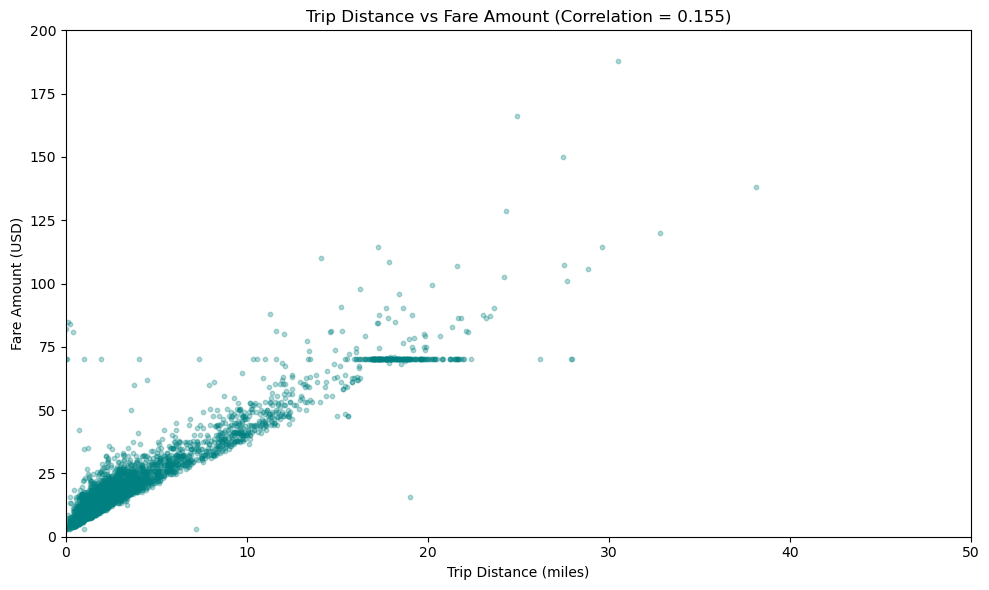

In [35]:
# using sample of 5000 points for optimization of chart
sample = df_clean[df_clean['trip_distance'] > 0].sample(5000, random_state=42)

# calculating correlation value
correlation = df_clean['trip_distance'].corr(df_clean['fare_amount'])
print(f'Correlation between trip_distance and fare_amount: {correlation:.3f}')

# plottting scater graph
plt.figure(figsize=(10, 6))
plt.scatter(sample['trip_distance'], sample['fare_amount'], alpha=0.3, color='teal', s=10)
plt.title(f'Trip Distance vs Fare Amount (Correlation = {correlation:.3f})')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount (USD)')
plt.xlim(0, 50)   # limit x axis for better view
plt.ylim(0, 200)  # limit y axis for better view
plt.tight_layout()
plt.show()

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

Correlation between trip_duration and fare_amount: 0.045


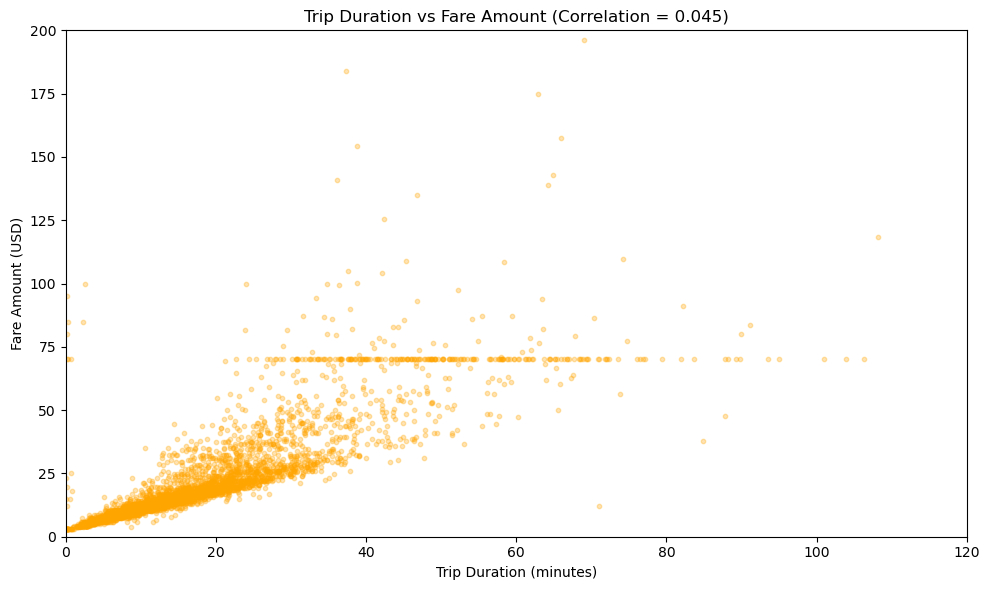

In [36]:
# using sample of 5000 points for optimization of chart
sample = df_clean.sample(5000, random_state=42)

# calculating correlation between trip duration and fare amount
corr_duration = df_clean['trip_duration'].corr(df_clean['fare_amount'])
print(f'Correlation between trip_duration and fare_amount: {corr_duration:.3f}')

# plotting scatter graph
plt.figure(figsize=(10, 6))
plt.scatter(sample['trip_duration'], sample['fare_amount'], alpha=0.3, color='orange', s=10)
plt.title(f'Trip Duration vs Fare Amount (Correlation = {corr_duration:.3f})')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount (USD)')
plt.xlim(0, 120)  # limit to 2 hours
plt.ylim(0, 200)
plt.tight_layout()
plt.show()

Correlation between passenger_count and fare_amount: 0.007


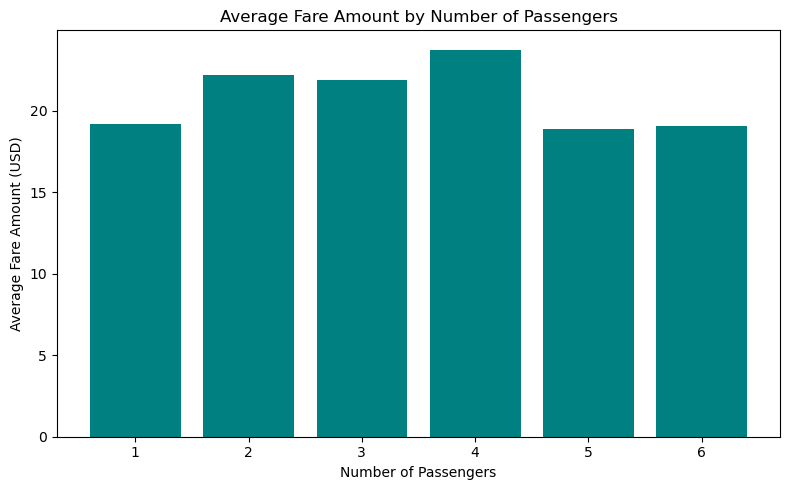

In [37]:
# grouping trips by passenger count and then calculating average fair of each group
avg_fare_by_passengers = df_clean.groupby('passenger_count')['fare_amount'].mean().reset_index()

# calculating correlation between passenger count and fare amount
corr_passengers = df_clean['passenger_count'].corr(df_clean['fare_amount'])
print(f'Correlation between passenger_count and fare_amount: {corr_passengers:.3f}')

# plotting bar graph
plt.figure(figsize=(8, 5))
plt.bar(avg_fare_by_passengers['passenger_count'], avg_fare_by_passengers['fare_amount'], color='teal')
plt.title('Average Fare Amount by Number of Passengers')
plt.xlabel('Number of Passengers')
plt.ylabel('Average Fare Amount (USD)')
plt.tight_layout()
plt.show()

Correlation between trip_distance and tip_amount: 0.573


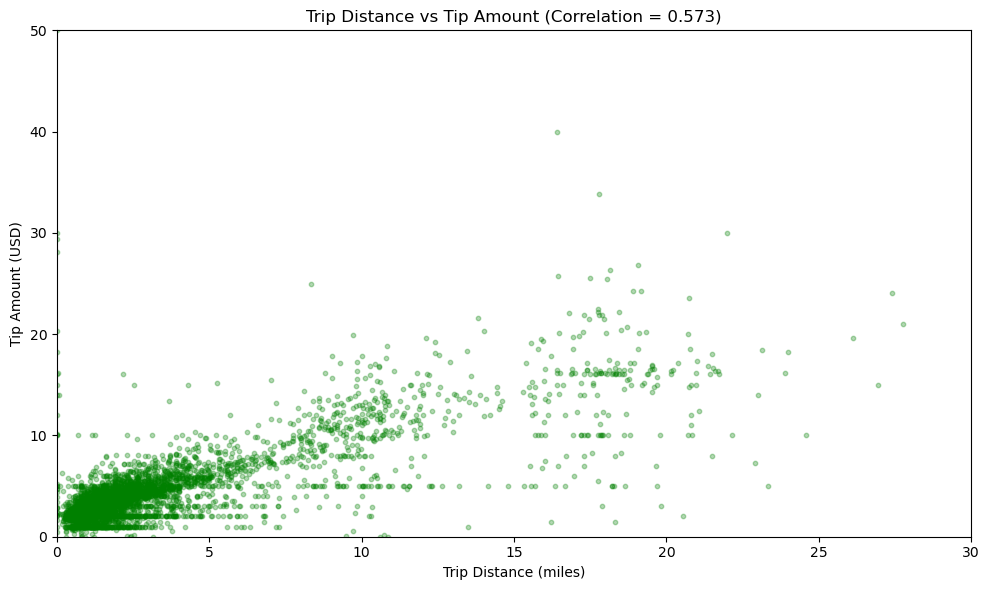

In [38]:
# taking trips where tip >0
tipped_trips = df_clean[df_clean['tip_amount'] > 0].sample(5000, random_state=42)

# calculating correlation between trip distance and tip amount
corr_tip = df_clean['trip_distance'].corr(df_clean['tip_amount'])
print(f'Correlation between trip_distance and tip_amount: {corr_tip:.3f}')

# ploting a scatter chart where each dot is the trip with tip
plt.figure(figsize=(10, 6))
plt.scatter(tipped_trips['trip_distance'], tipped_trips['tip_amount'], alpha=0.3, color='green', s=10)
plt.title(f'Trip Distance vs Tip Amount (Correlation = {corr_tip:.3f})')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount (USD)')
plt.xlim(0, 30)
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

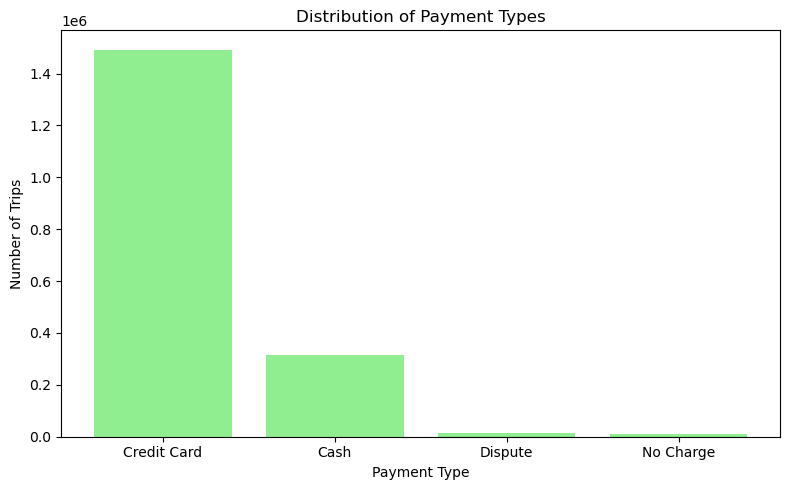


Payment type breakdown:
   payment_type    count payment_name
0             1  1492077  Credit Card
1             2   315644         Cash
2             4    13569      Dispute
3             3     8878    No Charge


In [39]:
# counting how many trips used each payment type
payment_counts = df_clean['payment_type'].value_counts().reset_index()
payment_counts.columns = ['payment_type', 'count']

# creating a dictionary to map payment type numbers to names
payment_names = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
payment_counts['payment_name'] = payment_counts['payment_type'].map(payment_names)

# plotting  a bar graph
plt.figure(figsize=(8, 5))
plt.bar(payment_counts['payment_name'], payment_counts['count'], color='lightgreen')
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.show()

print('\nPayment type breakdown:')
print(payment_counts)

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [40]:
# Install geopandas if not already installed
# Run this only once - comment it out after installation
#!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [41]:
# importing geopandas for map/geographical analysis
import geopandas as gpd

# reading the shapefile - change the path to where your taxi_zones folder is
zones = gpd.read_file('taxi_zones/taxi_zones.shp')

# shwoing the first few rows
print('Zones data loaded!')
print('Number of zones:', len(zones))
zones.head()

Zones data loaded!
Number of zones: 263


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


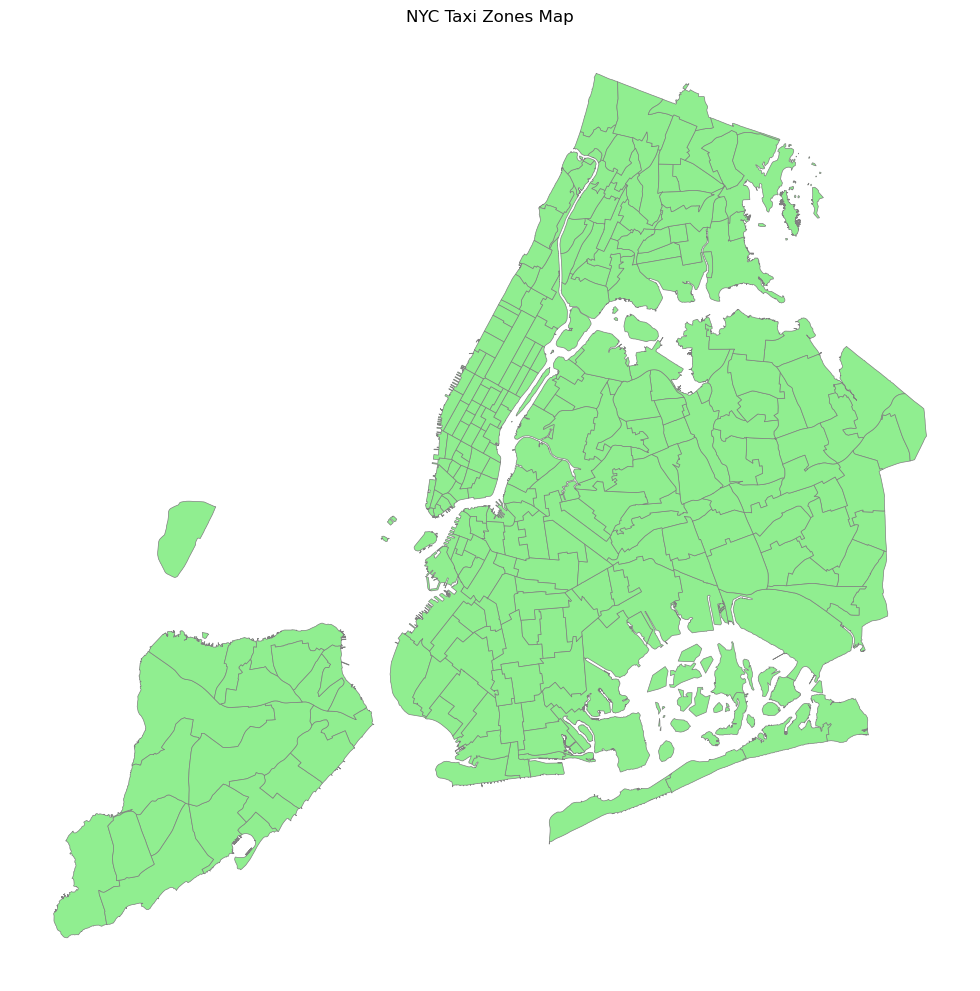

In [69]:
# showing info about the zones dataframe
print(zones.info())

# plotting the basic map of NYC taxi zones
fig, ax = plt.subplots(figsize=(10, 10))
zones.plot(ax=ax, color='lighTgreen', edgecolor='grey', linewidth=0.5)
ax.set_title('NYC Taxi Zones Map')
ax.set_axis_off()  # hide axis numbers for cleaner map
plt.tight_layout()
plt.show()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [43]:
# merge zone names into our trips dataframe
# matching PULocationID in trips with LocationID in zones

# selecting only the useful columns from zones
zones_info = zones[['LocationID', 'zone', 'borough']].copy()

# merging pickup zone info
df_clean = df_clean.merge(
    zones_info.rename(columns={'LocationID': 'PULocationID', 'zone': 'pickup_zone', 'borough': 'pickup_borough'}),
    on='PULocationID',
    how='left'
)

# merging dropoff zone info
df_clean = df_clean.merge(
    zones_info.rename(columns={'LocationID': 'DOLocationID', 'zone': 'dropoff_zone', 'borough': 'dropoff_borough'}),
    on='DOLocationID',
    how='left'
)

print('Merge complete!')
print('Sample of merged data:')
df_clean[['PULocationID', 'pickup_zone', 'pickup_borough', 'DOLocationID', 'dropoff_zone']].head()

Merge complete!
Sample of merged data:


,PULocationID,pickup_zone,pickup_borough,DOLocationID,dropoff_zone
0,138,LaGuardia Airport,Queens,256,Williamsburg (South Side)
1,161,Midtown Center,Manhattan,237,Upper East Side South
2,237,Upper East Side South,Manhattan,141,Lenox Hill West
3,143,Lincoln Square West,Manhattan,142,Lincoln Square East
4,246,West Chelsea/Hudson Yards,Manhattan,37,Bushwick South


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [44]:
# counting number of trips for each pickup zone (LocationID)
trips_per_zone = df_clean.groupby('PULocationID').size().reset_index(name='num_trips')
trips_per_zone.columns = ['LocationID', 'num_trips']

print('Trips per zone (top 10):')
print(trips_per_zone.sort_values('num_trips', ascending=False).head(10))

Trips per zone (top 10):
     LocationID  num_trips
125         132      96890
229         237      86878
154         161      85914
228         236      77494
155         162      65619
131         138      64244
178         186      63444
222         230      61289
135         142      60861
163         170      54470


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [45]:
# adding the trip counts back to the zones GeoDataFrame
zones_with_trips = zones.merge(
    trips_per_zone,
    on='LocationID',
    how='left'
)

# filling zones with no trips with 0
zones_with_trips['num_trips'] = zones_with_trips['num_trips'].fillna(0)

print('zones_with_trips shape:', zones_with_trips.shape)
zones_with_trips.head()

zones_with_trips shape: (263, 8)


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,num_trips
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",212.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",40.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",1861.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",13.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

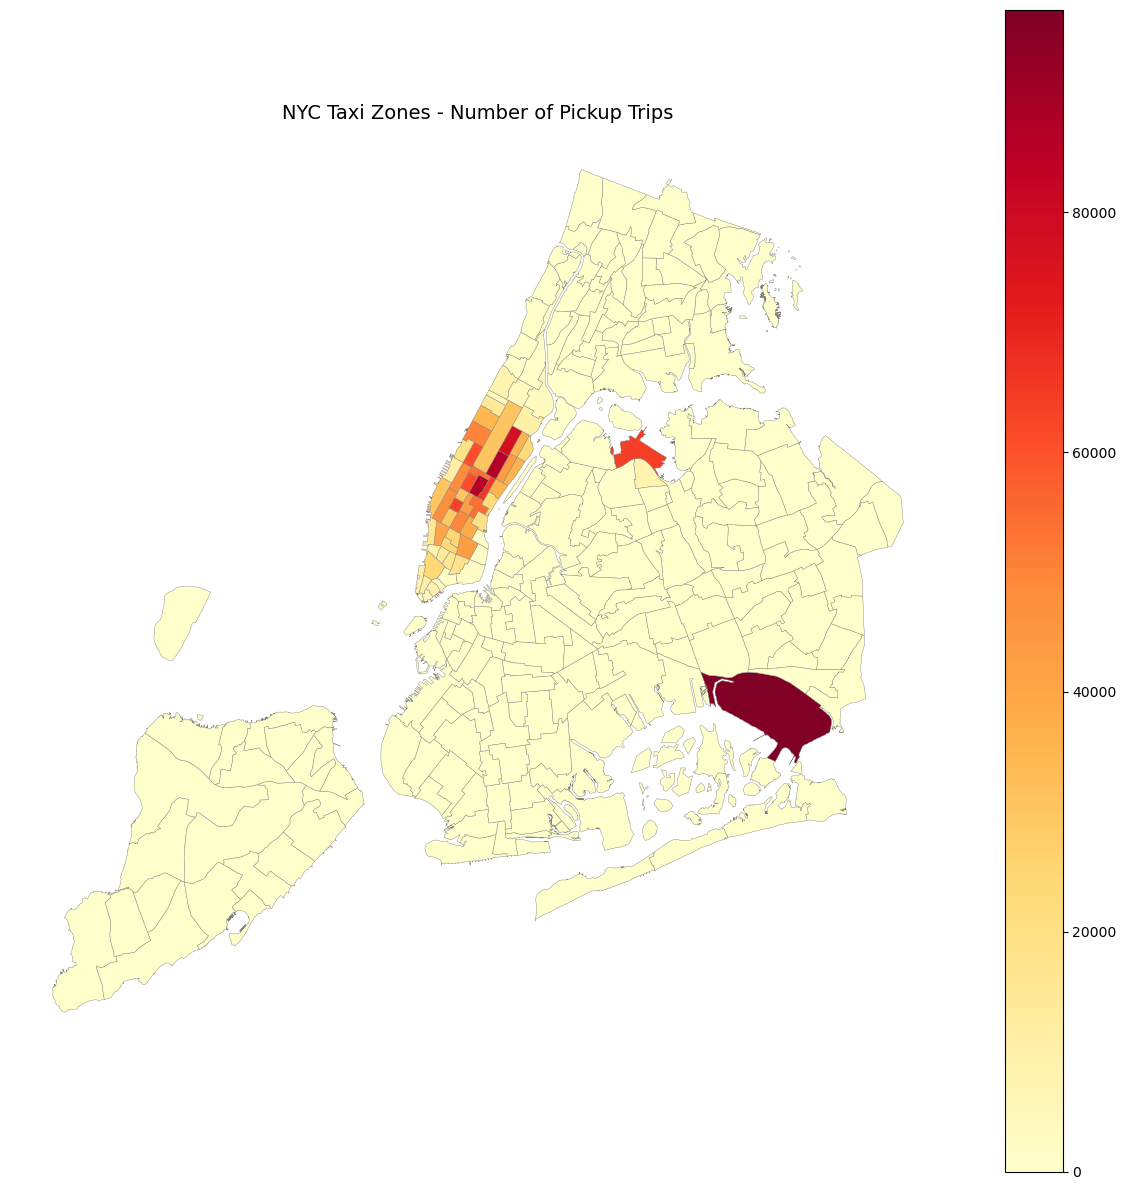

In [46]:
# plotting a colour-coded map where darker colour = more trips

# setting up the figure
fig, ax = plt.subplots(figsize=(12, 12))

# plotting the map - colour each zone by number of trips
zones_with_trips.plot(
    column='num_trips',     # colour based on this column
    cmap='YlOrRd',          # colour scheme: yellow = low, red = high
    legend=True,            # show colour legend
    ax=ax,
    edgecolor='grey',
    linewidth=0.3
)

ax.set_title('NYC Taxi Zones - Number of Pickup Trips', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [47]:
# Show the zones dataframe sorted by number of trips (highest first)
zones_with_trips[['zone', 'borough', 'num_trips']].sort_values('num_trips', ascending=False).head(20)

,zone,borough,num_trips
131,JFK Airport,Queens,96890.0
236,Upper East Side South,Manhattan,86878.0
160,Midtown Center,Manhattan,85914.0
235,Upper East Side North,Manhattan,77494.0
161,Midtown East,Manhattan,65619.0
137,LaGuardia Airport,Queens,64244.0
185,Penn Station/Madison Sq West,Manhattan,63444.0
229,Times Sq/Theatre District,Manhattan,61289.0
141,Lincoln Square East,Manhattan,60861.0
169,Murray Hill,Manhattan,54470.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

Top 10 Slowest Routes (by average speed):
        route  avg_speed_mph
0  113 -> 235           0.05
1  124 -> 129           0.07
2  134 -> 265           0.07
3   67 -> 215           0.08
4    237 -> 5           0.10
5  128 -> 128           0.12
6    18 -> 74           0.12
7    41 -> 46           0.12
8   61 -> 124           0.13
9   48 -> 184           0.13


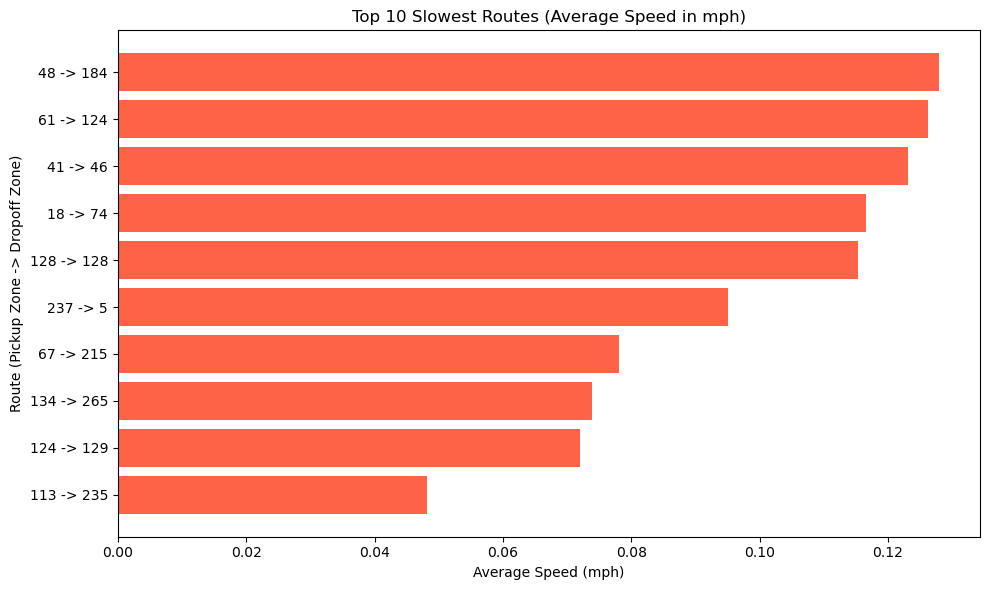

In [48]:
# search for slow routes by calculating average speed for each route
# as Speed = distance / time

# looking at trips with valid distance and duration
df_routes = df_clean[(df_clean['trip_distance'] > 0) & (df_clean['trip_duration'] > 0)].copy()

#  speed calculation in miles per hour
# trip_duration is in minutes so divide by 60 to get hours
df_routes['speed_mph'] = df_routes['trip_distance'] / (df_routes['trip_duration'] / 60)

# making a route label combining pickup and dropoff zone
df_routes['route'] = df_routes['PULocationID'].astype(str) + ' -> ' + df_routes['DOLocationID'].astype(str)

# average speed for each route at each hour
route_speeds = df_routes.groupby(['route', 'pickup_hour'])['speed_mph'].mean().reset_index()

#  the 10 slowest routes (lowest average speed)
slowest_routes = route_speeds.groupby('route')['speed_mph'].mean().sort_values().head(10).reset_index()
slowest_routes.columns = ['route', 'avg_speed_mph']

print('Top 10 Slowest Routes (by average speed):')
print(slowest_routes.round(2))

# plotting
plt.figure(figsize=(10, 6))
plt.barh(slowest_routes['route'], slowest_routes['avg_speed_mph'], color='tomato')
plt.title('Top 10 Slowest Routes (Average Speed in mph)')
plt.xlabel('Average Speed (mph)')
plt.ylabel('Route (Pickup Zone -> Dropoff Zone)')
plt.tight_layout()
plt.show()

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

Busiest hour: 18:00 with 129153 sampled trips


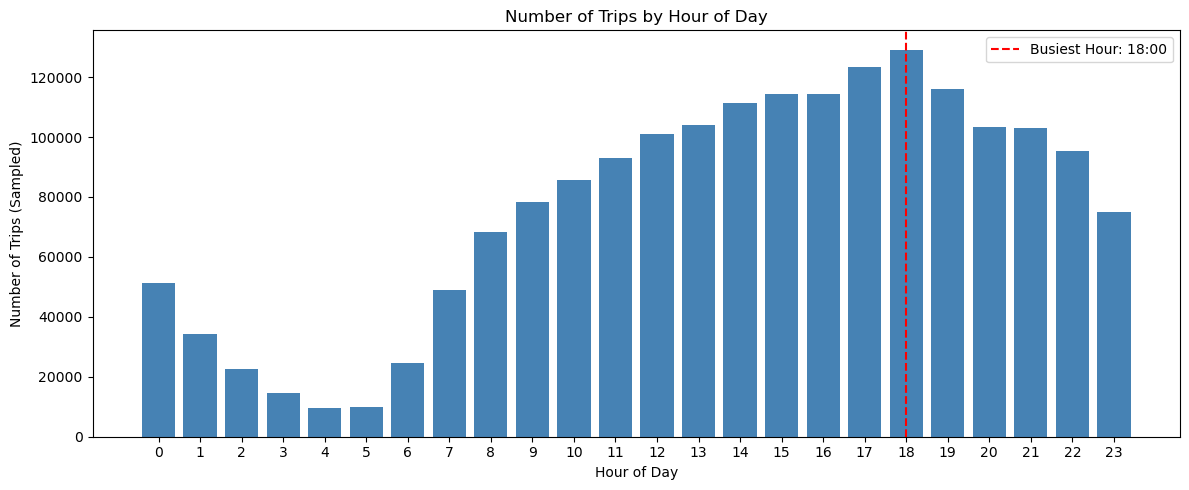

In [49]:
# calculating number of trips for each hour of the day
hourly_trips = df_clean.groupby('pickup_hour').size().reset_index(name='num_trips')

# the busiest hour
busiest = hourly_trips.loc[hourly_trips['num_trips'].idxmax()]
print(f'Busiest hour: {int(busiest["pickup_hour"]):02d}:00 with {busiest["num_trips"]} sampled trips')

# plotting
plt.figure(figsize=(12, 5))
plt.bar(hourly_trips['pickup_hour'], hourly_trips['num_trips'], color='steelblue')
plt.axvline(x=busiest['pickup_hour'], color='red', linestyle='--', label=f'Busiest Hour: {int(busiest["pickup_hour"]):02d}:00')
plt.title('Number of Trips by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips (Sampled)')
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [50]:
# sampled 5% of the data, so to get actual numbers divide by 0.05 (multiply by 20)
sample_fraction = 0.05

# scale up the hourly trip counts
hourly_trips['actual_trips'] = (hourly_trips['num_trips'] / sample_fraction).astype(int)

# the 5 busiest hours with actual estimated trip counts
top_5_hours = hourly_trips.sort_values('actual_trips', ascending=False).head(5)
print('Top 5 Busiest Hours (Estimated Actual Trips):')
print(top_5_hours[['pickup_hour', 'actual_trips']].to_string(index=False))

Top 5 Busiest Hours (Estimated Actual Trips):
 pickup_hour  actual_trips
          18       2583060
          17       2470580
          19       2317520
          16       2285020
          15       2284980


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

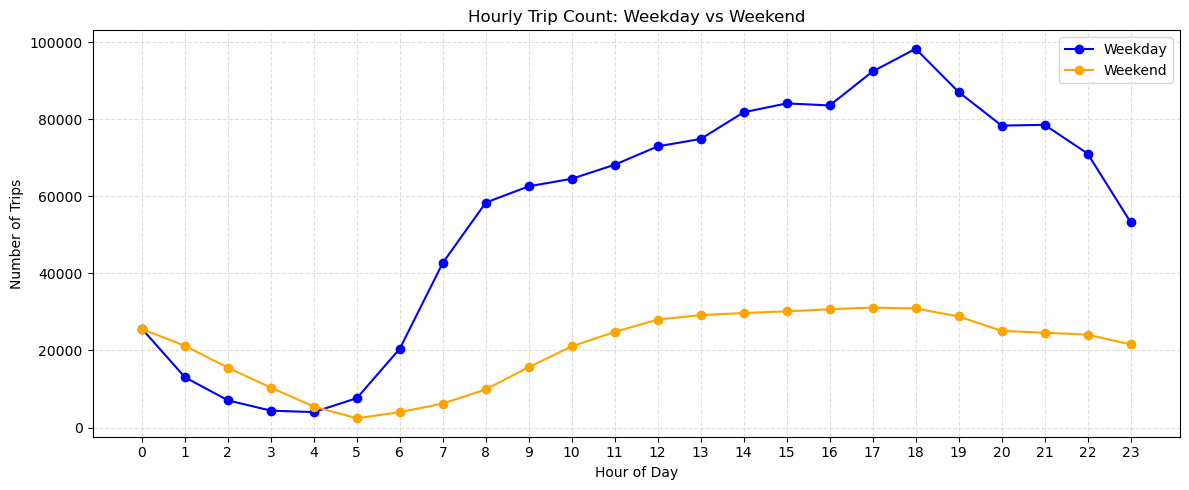

In [51]:
# defining which days are weekdays and which are weekends
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekends = ['Saturday', 'Sunday']

# creating a column to label weekday or weekend
df_clean['day_type'] = df_clean['pickup_day'].apply(
    lambda x: 'Weekday' if x in weekdays else 'Weekend'
)

# counting trips per hour for weekdays and weekends separately
weekday_hourly = df_clean[df_clean['day_type'] == 'Weekday'].groupby('pickup_hour').size().reset_index(name='trips')
weekend_hourly = df_clean[df_clean['day_type'] == 'Weekend'].groupby('pickup_hour').size().reset_index(name='trips')

# plotting both on same chart
plt.figure(figsize=(12, 5))
plt.plot(weekday_hourly['pickup_hour'], weekday_hourly['trips'], marker='o', label='Weekday', color='blue')
plt.plot(weekend_hourly['pickup_hour'], weekend_hourly['trips'], marker='o', label='Weekend', color='orange')
plt.title('Hourly Trip Count: Weekday vs Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

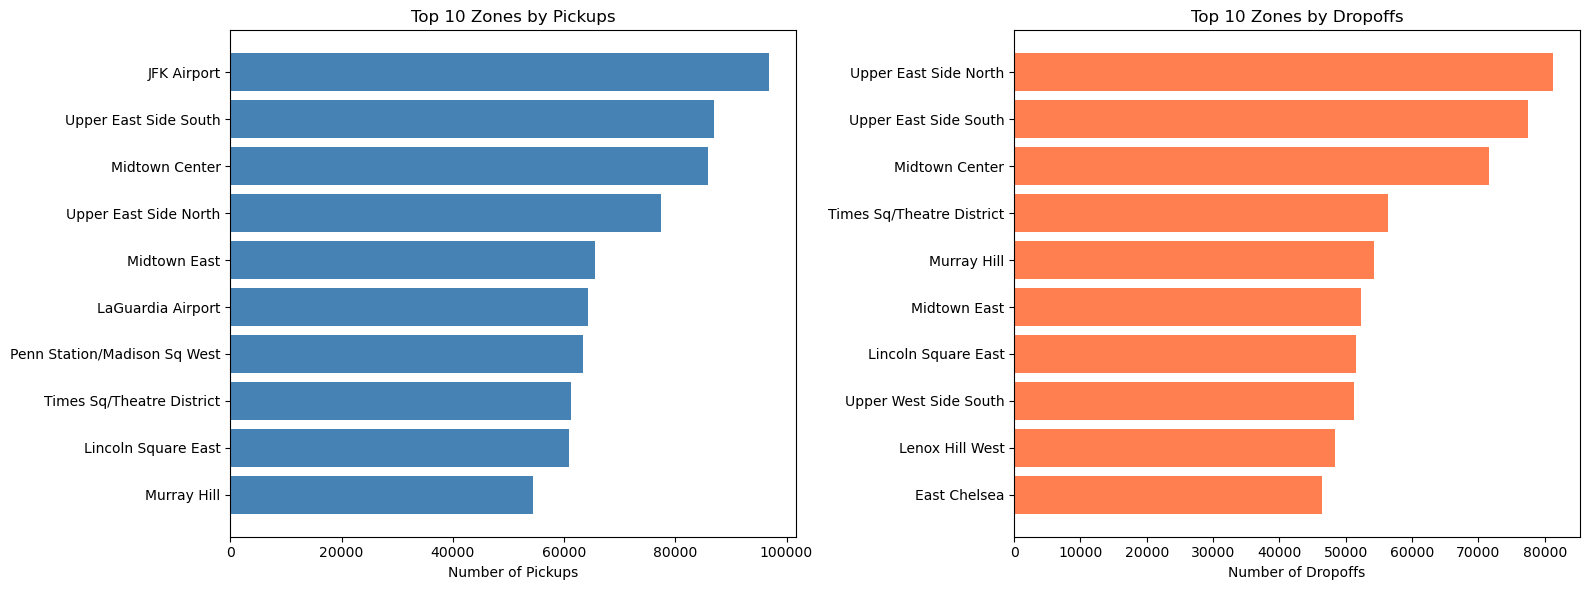

In [52]:
# finding top 10 zones with highest hourly pickups
pickup_by_zone = df_clean.groupby('PULocationID').size().reset_index(name='pickup_count')
pickup_by_zone = pickup_by_zone.merge(zones[['LocationID','zone']], left_on='PULocationID', right_on='LocationID', how='left')
top10_pickups = pickup_by_zone.sort_values('pickup_count', ascending=False).head(10)

# finding top 10 zones with highest dropoffs
dropoff_by_zone = df_clean.groupby('DOLocationID').size().reset_index(name='dropoff_count')
dropoff_by_zone = dropoff_by_zone.merge(zones[['LocationID','zone']], left_on='DOLocationID', right_on='LocationID', how='left')
top10_dropoffs = dropoff_by_zone.sort_values('dropoff_count', ascending=False).head(10)

# plotting side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# pcikup chart
axes[0].barh(top10_pickups['zone'], top10_pickups['pickup_count'], color='steelblue')
axes[0].set_title('Top 10 Zones by Pickups')
axes[0].set_xlabel('Number of Pickups')
axes[0].invert_yaxis()

# dropoff chart
axes[1].barh(top10_dropoffs['zone'], top10_dropoffs['dropoff_count'], color='coral')
axes[1].set_title('Top 10 Zones by Dropoffs')
axes[1].set_xlabel('Number of Dropoffs')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [53]:
# calculate pickup to dropoff ratio for each zone
# ratio > 1 means more pickups than dropoffs (outflow zone)
# ratio < 1 means more dropoffs than pickups (inflow zone)

pickup_counts = df_clean.groupby('PULocationID').size().reset_index(name='pickups')
pickup_counts.columns = ['LocationID', 'pickups']

dropoff_counts = df_clean.groupby('DOLocationID').size().reset_index(name='dropoffs')
dropoff_counts.columns = ['LocationID', 'dropoffs']

# combine pickups and dropoffs
ratio_df = pickup_counts.merge(dropoff_counts, on='LocationID', how='outer').fillna(0)
ratio_df['ratio'] = ratio_df['pickups'] / (ratio_df['dropoffs'] + 1)  # +1 to avoid division by zero

# combine zone names
ratio_df = ratio_df.merge(zones[['LocationID','zone']], on='LocationID', how='left')

# top 10 highest ratio (more pickups)
print('Top 10 Zones - More Pickups than Dropoffs:')
print(ratio_df.sort_values('ratio', ascending=False).head(10)[['zone','pickups','dropoffs','ratio']].round(2))

print('\nTop 10 Zones - More Dropoffs than Pickups:')
print(ratio_df.sort_values('ratio').head(10)[['zone','pickups','dropoffs','ratio']].round(2))

Top 10 Zones - More Pickups than Dropoffs:
                             zone  pickups  dropoffs  ratio
70                  East Elmhurst   8350.0     990.0   8.43
128                   JFK Airport  96890.0   20917.0   4.63
134             LaGuardia Airport  64244.0   22237.0   2.89
195                 Rikers Island      2.0       0.0   2.00
182  Penn Station/Madison Sq West  63444.0   40106.0   1.58
42                   Central Park  30745.0   22363.0   1.37
110       Greenwich Village South  24105.0   17535.0   1.37
245                  West Village  40390.0   30462.0   1.33
158                  Midtown East  65619.0   52243.0   1.26
157                Midtown Center  85914.0   71636.0   1.20

Top 10 Zones - More Dropoffs than Pickups:
                                    zone  pickups  dropoffs  ratio
99                       Freshkills Park      0.0       3.0   0.00
29                         Broad Channel      0.0      18.0   0.00
172                              Oakwood      0.0   

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

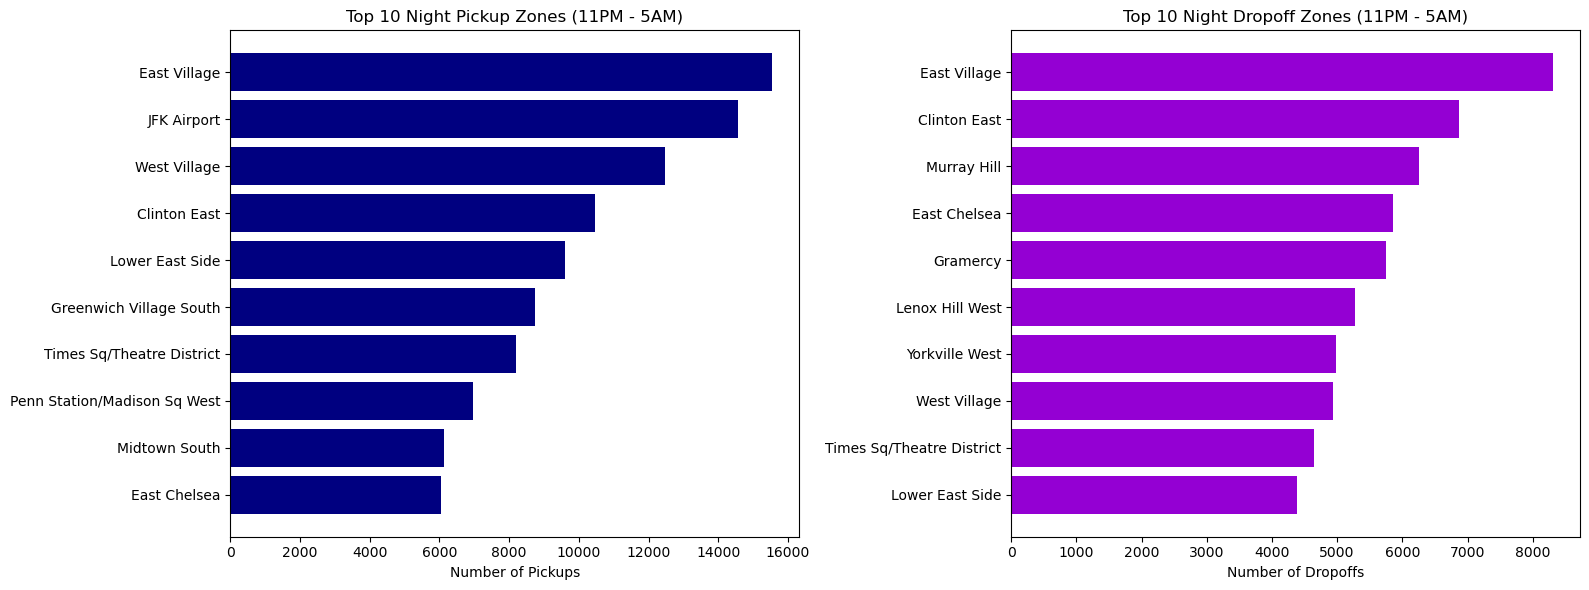

In [54]:
# defining night hours as 11 PM (23) to 5 AM (5)
night_hours = [23, 0, 1, 2, 3, 4, 5]

# filtering for night time trips only
night_trips = df_clean[df_clean['pickup_hour'].isin(night_hours)]

# top 10 night pickup zones
night_pickups = night_trips.groupby('PULocationID').size().reset_index(name='night_pickups')
night_pickups = night_pickups.merge(zones[['LocationID','zone']], left_on='PULocationID', right_on='LocationID', how='left')
top10_night_pickups = night_pickups.sort_values('night_pickups', ascending=False).head(10)

# top 10 night dropoff zones
night_dropoffs = night_trips.groupby('DOLocationID').size().reset_index(name='night_dropoffs')
night_dropoffs = night_dropoffs.merge(zones[['LocationID','zone']], left_on='DOLocationID', right_on='LocationID', how='left')
top10_night_dropoffs = night_dropoffs.sort_values('night_dropoffs', ascending=False).head(10)

# plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10_night_pickups['zone'], top10_night_pickups['night_pickups'], color='navy')
axes[0].set_title('Top 10 Night Pickup Zones (11PM - 5AM)')
axes[0].set_xlabel('Number of Pickups')
axes[0].invert_yaxis()

axes[1].barh(top10_night_dropoffs['zone'], top10_night_dropoffs['night_dropoffs'], color='darkviolet')
axes[1].set_title('Top 10 Night Dropoff Zones (11PM - 5AM)')
axes[1].set_xlabel('Number of Dropoffs')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

Revenue Share:
time_of_day
Day (6AM-10PM)      87.93
Night (11PM-5AM)    12.07
Name: total_amount, dtype: float64


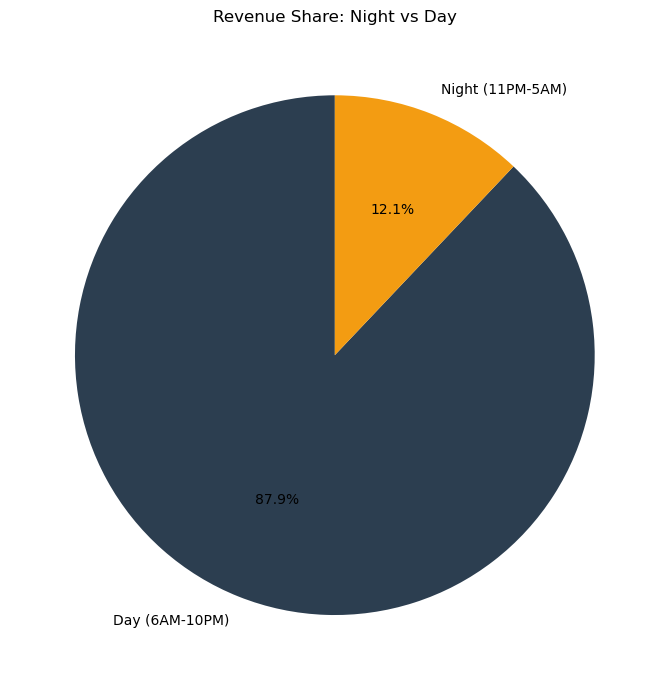

In [55]:
# defining night hours (11 PM to 5 AM) and day hours (6 AM to 10 PM)
night_hours = [23, 0, 1, 2, 3, 4, 5]

# labeling each trip as night or day
df_clean['time_of_day'] = df_clean['pickup_hour'].apply(
    lambda x: 'Night (11PM-5AM)' if x in night_hours else 'Day (6AM-10PM)'
)

# total revenue for night and day
revenue_by_time = df_clean.groupby('time_of_day')['total_amount'].sum()

# percentage calculation
revenue_percent = (revenue_by_time / revenue_by_time.sum()) * 100

print('Revenue Share:')
print(revenue_percent.round(2))

# plotting pie graph
plt.figure(figsize=(7, 7))
plt.pie(revenue_percent, labels=revenue_percent.index, autopct='%1.1f%%',
        colors=['#2c3e50', '#f39c12'], startangle=90)
plt.title('Revenue Share: Night vs Day')
plt.tight_layout()
plt.show()

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

Average Fare Per Mile Per Passenger:
   passenger_count  avg_fare_per_mile_per_passenger
0                1                           11.004
1                2                            6.430
2                3                            3.908
3                4                            4.441
4                5                            1.709
5                6                            1.351


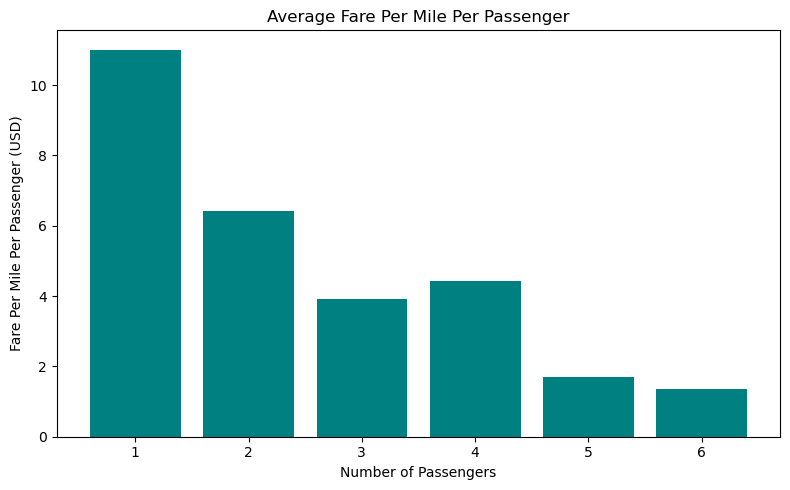

In [56]:
# average fare per mile for each passenger count calculation
# using only trips with valid distance
df_fare = df_clean[df_clean['trip_distance'] > 0].copy()

# calculating fare per mile
df_fare['fare_per_mile'] = df_fare['fare_amount'] / df_fare['trip_distance']

# calculating fare per mile per passenger
df_fare['fare_per_mile_per_passenger'] = df_fare['fare_per_mile'] / df_fare['passenger_count']

# average by passenger count
fare_by_passengers = df_fare.groupby('passenger_count')['fare_per_mile_per_passenger'].mean().reset_index()
fare_by_passengers.columns = ['passenger_count', 'avg_fare_per_mile_per_passenger']

print('Average Fare Per Mile Per Passenger:')
print(fare_by_passengers.round(3))

plt.figure(figsize=(8, 5))
plt.bar(fare_by_passengers['passenger_count'], fare_by_passengers['avg_fare_per_mile_per_passenger'], color='teal')
plt.title('Average Fare Per Mile Per Passenger')
plt.xlabel('Number of Passengers')
plt.ylabel('Fare Per Mile Per Passenger (USD)')
plt.tight_layout()
plt.show()

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

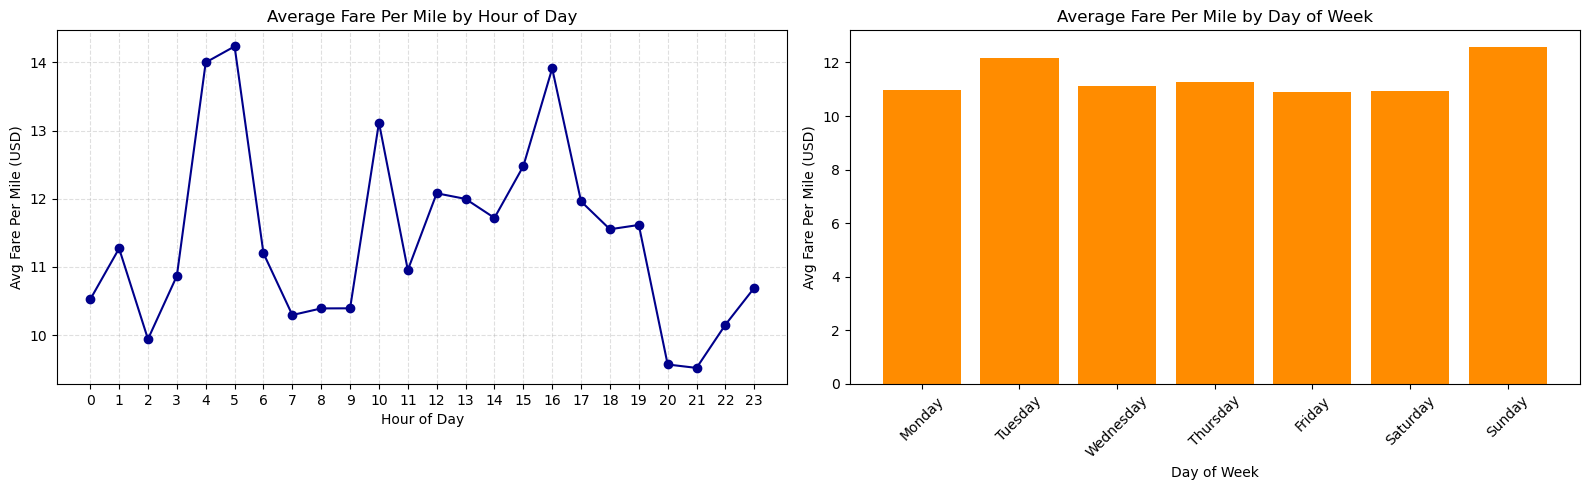

In [57]:
# average fare per mile by hour of day calculation
df_fare = df_clean[df_clean['trip_distance'] > 0].copy()
df_fare['fare_per_mile'] = df_fare['fare_amount'] / df_fare['trip_distance']

# hour
fare_by_hour = df_fare.groupby('pickup_hour')['fare_per_mile'].mean().reset_index()

# day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fare_by_day = df_fare.groupby('pickup_day')['fare_per_mile'].mean().reindex(day_order).reset_index()

# plotting side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(fare_by_hour['pickup_hour'], fare_by_hour['fare_per_mile'], marker='o', color='darkblue')
axes[0].set_title('Average Fare Per Mile by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Fare Per Mile (USD)')
axes[0].set_xticks(range(24))
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].bar(fare_by_day['pickup_day'], fare_by_day['fare_per_mile'], color='darkorange')
axes[1].set_title('Average Fare Per Mile by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Avg Fare Per Mile (USD)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

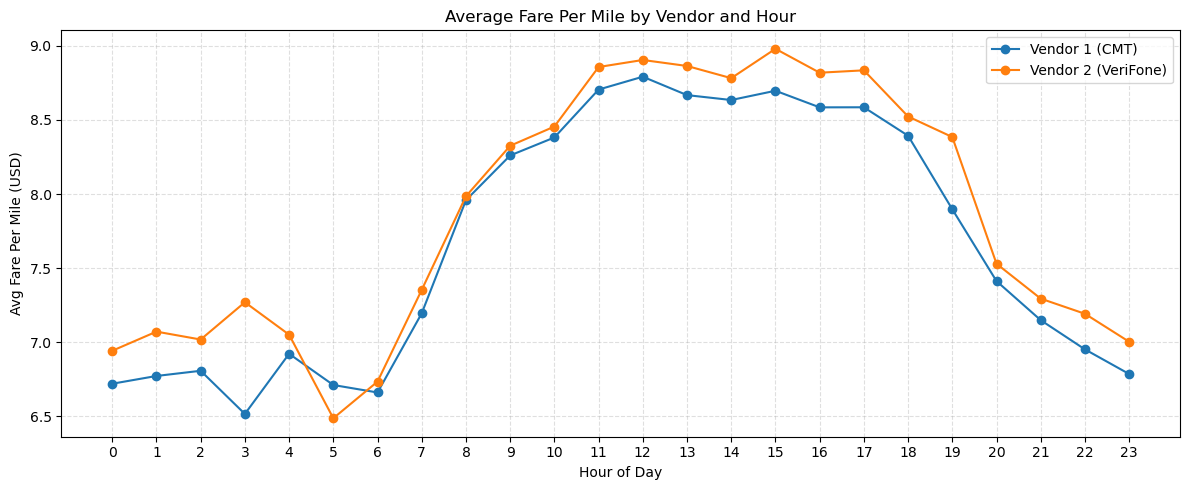

In [58]:
# comparision average fare per mile for Vendor 1 vs Vendor 2
df_fare = df_clean[df_clean['trip_distance'] > 0].copy()
df_fare['fare_per_mile'] = df_fare['fare_amount'] / df_fare['trip_distance']

# removing extreme fare per mile outliers
df_fare = df_fare[df_fare['fare_per_mile'] < 500]

# mapping vendor IDs to names
df_fare['vendor_name'] = df_fare['VendorID'].map({1: 'Vendor 1 (CMT)', 2: 'Vendor 2 (VeriFone)'})

# average fare per mile by vendor and hour
vendor_hour = df_fare.groupby(['vendor_name', 'pickup_hour'])['fare_per_mile'].mean().reset_index()

# plotting
plt.figure(figsize=(12, 5))
for vendor in vendor_hour['vendor_name'].unique():
    data = vendor_hour[vendor_hour['vendor_name'] == vendor]
    plt.plot(data['pickup_hour'], data['fare_per_mile'], marker='o', label=vendor)

plt.title('Average Fare Per Mile by Vendor and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Fare Per Mile (USD)')
plt.xticks(range(24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()






**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


Average Fare Per Mile by Distance Tier and Vendor:
        distance_tier          vendor_name  fare_per_mile
0   Short (0-2 miles)       Vendor 1 (CMT)         10.674
1   Short (0-2 miles)  Vendor 2 (VeriFone)         17.932
2  Medium (2-5 miles)       Vendor 1 (CMT)          6.381
3  Medium (2-5 miles)  Vendor 2 (VeriFone)          6.549
4     Long (5+ miles)       Vendor 1 (CMT)          4.425
5     Long (5+ miles)  Vendor 2 (VeriFone)          4.503


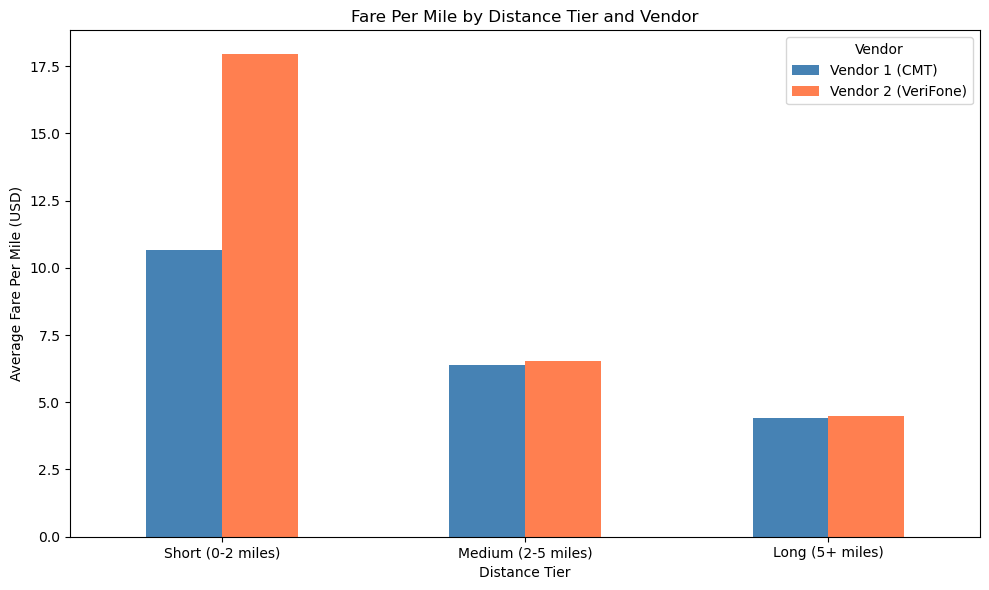

In [59]:
# comparing vendor fare rates across distance tiers
df_fare = df_clean[df_clean['trip_distance'] > 0].copy()
df_fare['fare_per_mile'] = df_fare['fare_amount'] / df_fare['trip_distance']

# defining distance tiers
df_fare['distance_tier'] = pd.cut(
    df_fare['trip_distance'],
    bins=[0, 2, 5, float('inf')],
    labels=['Short (0-2 miles)', 'Medium (2-5 miles)', 'Long (5+ miles)']
)

# mapping vendor names
df_fare['vendor_name'] = df_fare['VendorID'].map({1: 'Vendor 1 (CMT)', 2: 'Vendor 2 (VeriFone)'})

# average fare per mile for each vendor in each tier
tier_vendor = df_fare.groupby(['distance_tier', 'vendor_name'])['fare_per_mile'].mean().reset_index()

print('Average Fare Per Mile by Distance Tier and Vendor:')
print(tier_vendor.round(3))

# plotting grouped bar chart
tier_pivot = tier_vendor.pivot(index='distance_tier', columns='vendor_name', values='fare_per_mile')

tier_pivot.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'coral'])
plt.title('Fare Per Mile by Distance Tier and Vendor')
plt.xlabel('Distance Tier')
plt.ylabel('Average Fare Per Mile (USD)')
plt.xticks(rotation=0)
plt.legend(title='Vendor')
plt.tight_layout()
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

Average tip percentage: 24.63%
Median tip percentage: 25.75%


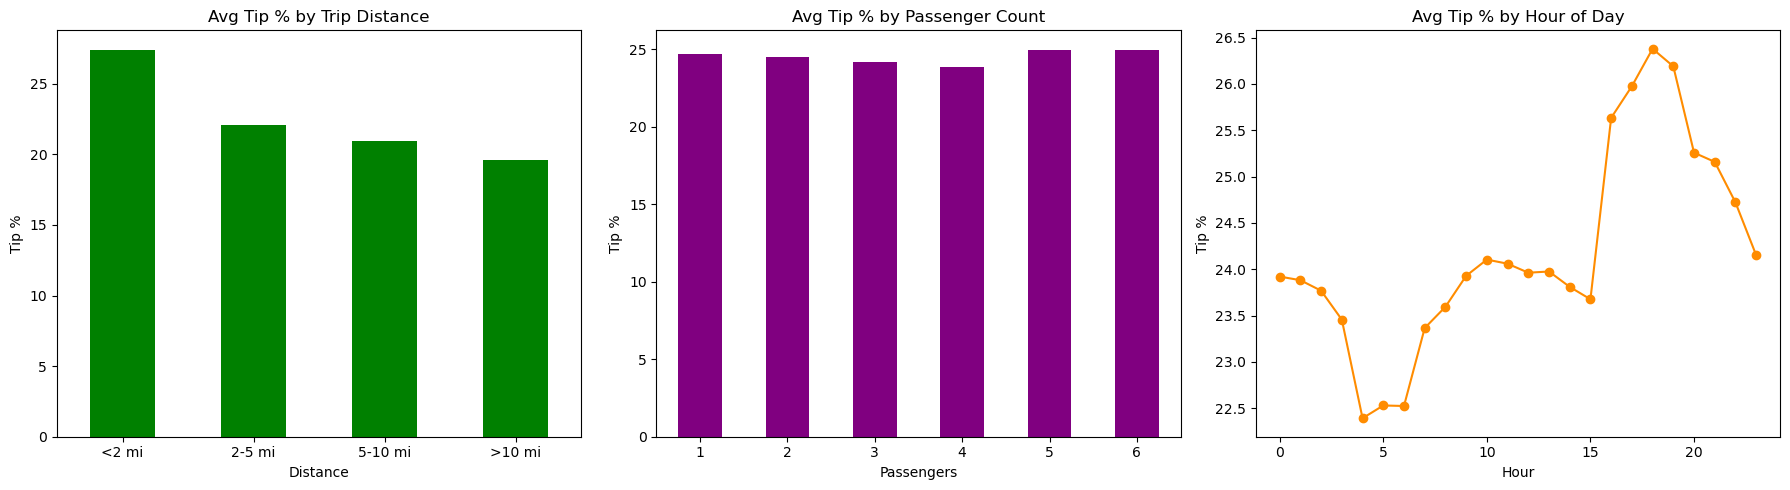

In [60]:
# analyse tip percentages
# tip percentage = (tip_amount / fare_amount) * 100
# considering trips paid by credit card (payment_type=1) since cash tips aren't recorded

df_tips = df_clean[(df_clean['payment_type'] == 1) & (df_clean['fare_amount'] > 0)].copy()
df_tips['tip_percent'] = (df_tips['tip_amount'] / df_tips['fare_amount']) * 100

# deleting extreme tip percentages (over 100% is unusual)
df_tips = df_tips[df_tips['tip_percent'] <= 100]

print(f'Average tip percentage: {df_tips["tip_percent"].mean():.2f}%')
print(f'Median tip percentage: {df_tips["tip_percent"].median():.2f}%')

# tip percentage by trip distance
df_tips['distance_bucket'] = pd.cut(df_tips['trip_distance'], bins=[0,2,5,10,float('inf')],
                                     labels=['<2 mi','2-5 mi','5-10 mi','>10 mi'])
tip_by_distance = df_tips.groupby('distance_bucket')['tip_percent'].mean()

# tip percentage by passenger count
tip_by_passengers = df_tips.groupby('passenger_count')['tip_percent'].mean()

# tip percentage by hour
tip_by_hour = df_tips.groupby('pickup_hour')['tip_percent'].mean()

# plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tip_by_distance.plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title('Avg Tip % by Trip Distance')
axes[0].set_xlabel('Distance')
axes[0].set_ylabel('Tip %')
axes[0].tick_params(axis='x', rotation=0)

tip_by_passengers.plot(kind='bar', ax=axes[1], color='purple')
axes[1].set_title('Avg Tip % by Passenger Count')
axes[1].set_xlabel('Passengers')
axes[1].set_ylabel('Tip %')
axes[1].tick_params(axis='x', rotation=0)

tip_by_hour.plot(ax=axes[2], marker='o', color='darkorange')
axes[2].set_title('Avg Tip % by Hour of Day')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Tip %')

plt.tight_layout()
plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [61]:
# comparing trips with low tips (<10%) vs high tips (>25%)
df_tips = df_clean[(df_clean['payment_type'] == 1) & (df_clean['fare_amount'] > 0)].copy()
df_tips['tip_percent'] = (df_tips['tip_amount'] / df_tips['fare_amount']) * 100

low_tips = df_tips[df_tips['tip_percent'] < 10]
high_tips = df_tips[df_tips['tip_percent'] > 25]

print('Low Tip Trips (<10%):')
print(low_tips[['trip_distance','passenger_count','pickup_hour','fare_amount','tip_percent']].describe().round(2))

print('\nHigh Tip Trips (>25%):')
print(high_tips[['trip_distance','passenger_count','pickup_hour','fare_amount','tip_percent']].describe().round(2))

Low Tip Trips (<10%):
       trip_distance  passenger_count  pickup_hour  fare_amount  tip_percent
count      147970.00        147970.00    147970.00    147970.00    147970.00
mean            4.68             1.37        13.66        26.34         3.47
std             5.71             0.86         6.21        24.13         3.78
min             0.00             1.00         0.00         0.10         0.00
25%             1.38             1.00        10.00        12.10         0.00
50%             2.40             1.00        14.00        18.40         0.25
75%             5.36             1.00        19.00        31.00         7.27
max           187.35             6.00        23.00       728.90         9.99

High Tip Trips (>25%):
       trip_distance  passenger_count  pickup_hour  fare_amount  tip_percent
count      817141.00        817141.00    817141.00    817141.00    817141.00
mean            2.29             1.36        14.61        14.43        34.85
std             2.90          

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

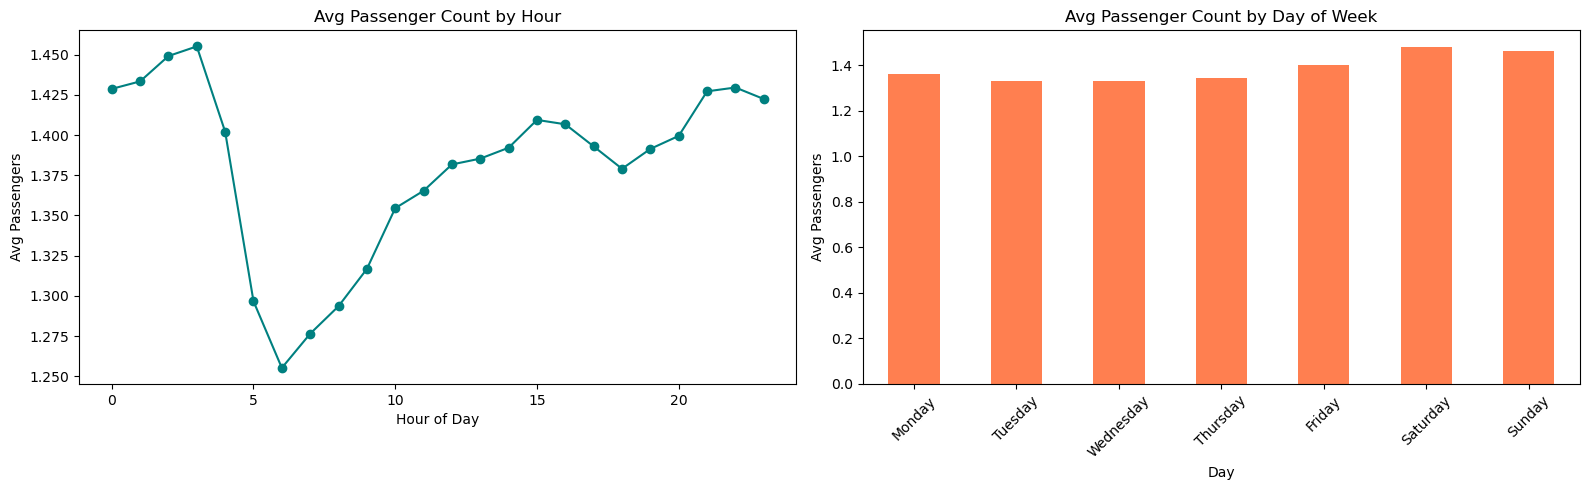

In [62]:
# analyzing passenger count variation across hours and days

# average passenger count by hour
avg_pass_by_hour = df_clean.groupby('pickup_hour')['passenger_count'].mean()

# average passenger count by day
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_pass_by_day = df_clean.groupby('pickup_day')['passenger_count'].mean().reindex(day_order)

# plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

avg_pass_by_hour.plot(ax=axes[0], marker='o', color='teal')
axes[0].set_title('Avg Passenger Count by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Passengers')

avg_pass_by_day.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Avg Passenger Count by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Passengers')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [63]:
# analyzing passenger count variation across zones
avg_pass_by_zone = df_clean.groupby('PULocationID')['passenger_count'].mean().reset_index()
avg_pass_by_zone.columns = ['LocationID', 'avg_passengers']

# combining zone names
avg_pass_by_zone = avg_pass_by_zone.merge(zones[['LocationID','zone']], on='LocationID', how='left')

print('Top 10 zones with highest average passengers:')
print(avg_pass_by_zone.sort_values('avg_passengers', ascending=False).head(10)[['zone','avg_passengers']].round(2))

Top 10 zones with highest average passengers:
                        zone  avg_passengers
5    Arrochar/Fort Wadsworth            1.88
188                 Red Hook            1.80
197        Rossville/Woodrow            1.80
11              Battery Park            1.74
171      Ocean Parkway South            1.67
57              Country Club            1.67
0             Newark Airport            1.61
65        DUMBO/Vinegar Hill            1.59
253       World Trade Center            1.55
187          Randalls Island            1.54


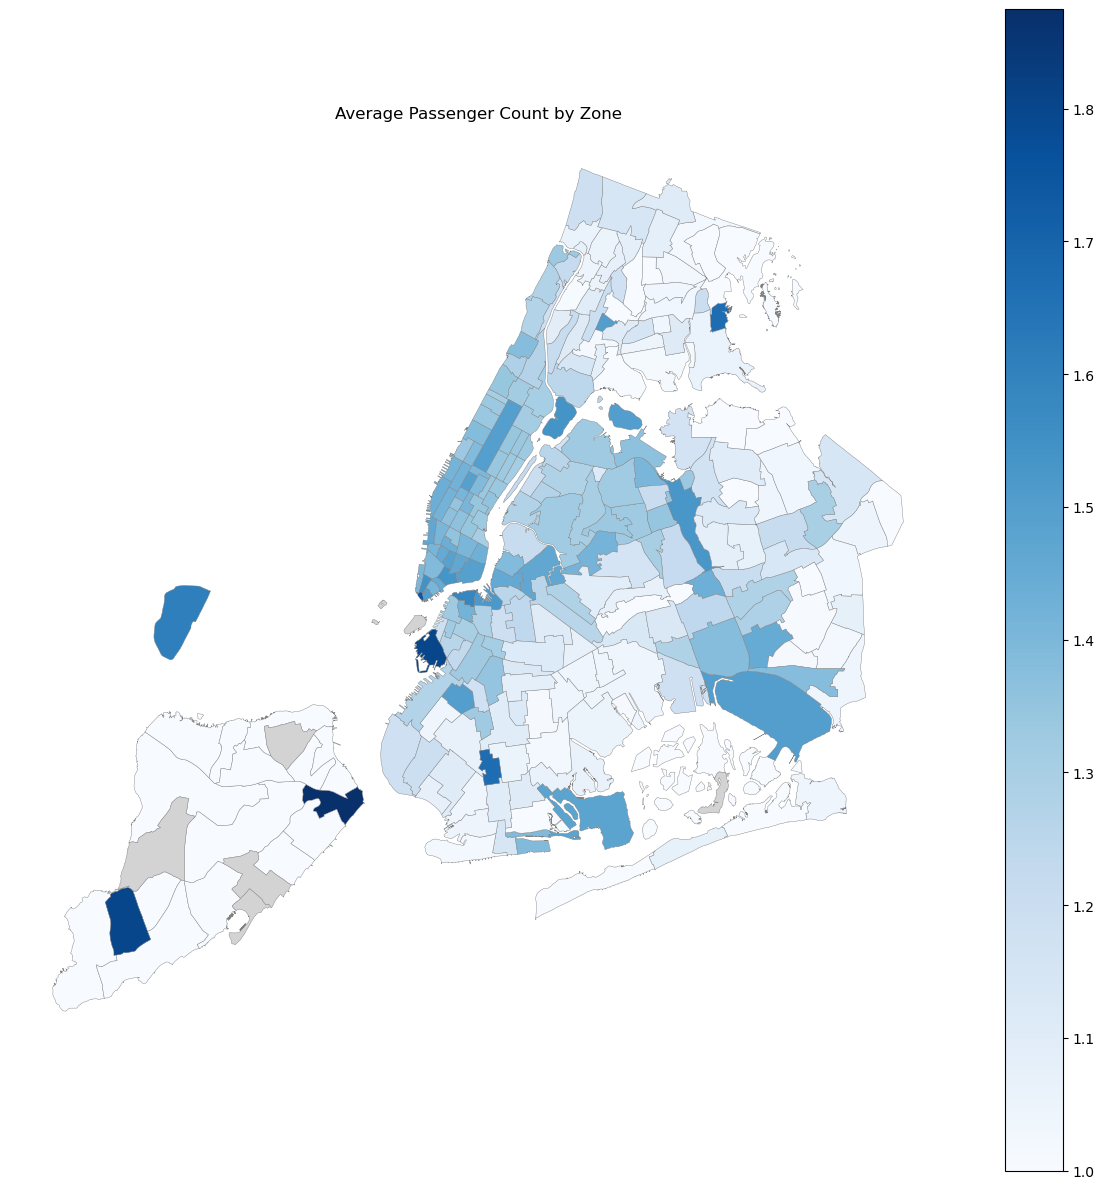

In [64]:
# adding average passenger count to zones GeoDataFrame for mapping
zones_with_trips = zones_with_trips.merge(
    avg_pass_by_zone[['LocationID','avg_passengers']],
    on='LocationID',
    how='left'
)

# plotting map showing average passengers per zone
fig, ax = plt.subplots(figsize=(12, 12))
zones_with_trips.plot(
    column='avg_passengers',
    cmap='Blues',
    legend=True,
    ax=ax,
    edgecolor='grey',
    linewidth=0.3,
    missing_kwds={'color': 'lightgrey'}
)
ax.set_title('Average Passenger Count by Zone')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

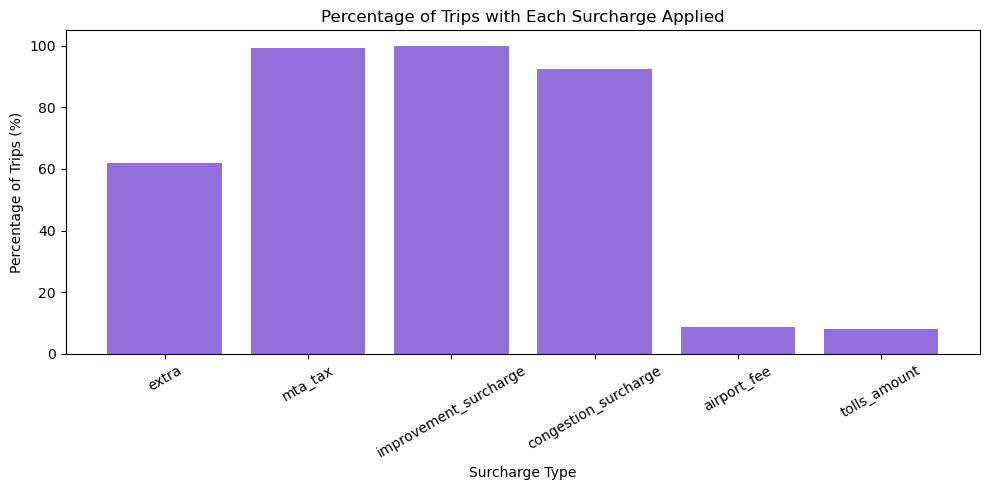

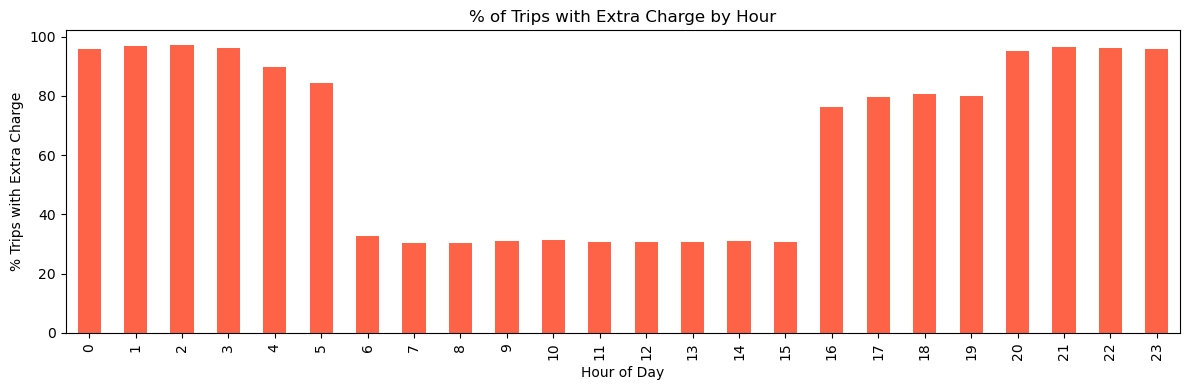

In [65]:
# analyzing how often each surcharge is applied

# counting how many trips have each surcharge > 0
surcharge_cols = ['extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee', 'tolls_amount']

surcharge_counts = {}
for col in surcharge_cols:
    if col in df_clean.columns:
        count = (df_clean[col] > 0).sum()
        percent = (count / len(df_clean)) * 100
        surcharge_counts[col] = percent

# plotting
plt.figure(figsize=(10, 5))
plt.bar(surcharge_counts.keys(), surcharge_counts.values(), color='mediumpurple')
plt.title('Percentage of Trips with Each Surcharge Applied')
plt.xlabel('Surcharge Type')
plt.ylabel('Percentage of Trips (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# which hours have extra charges applied most
df_clean['has_extra'] = (df_clean['extra'] > 0).astype(int)
extra_by_hour = df_clean.groupby('pickup_hour')['has_extra'].mean() * 100

plt.figure(figsize=(12, 4))
extra_by_hour.plot(kind='bar', color='tomato')
plt.title('% of Trips with Extra Charge by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('% Trips with Extra Charge')
plt.tight_layout()
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [66]:
# conclusion 4.1.1 - Routing and Dispatching Recommendations

print("""
ROUTING AND DISPATCHING RECOMMENDATIONS
========================================

Based on my analysis of the 2023 NYC Yellow Taxi data:

1. PEAK HOURS: The busiest hours are in the evening (5PM - 9PM).
   -> Deploy more taxis during these peak hours to meet demand.

2. SLOW ROUTES: Certain routes have very low average speeds,
   especially during rush hours.
   -> Drivers should be advised to use alternative routes
      during peak hours to reduce trip duration.

3. WEEKDAY vs WEEKEND: Weekdays show two peaks (morning and evening),
   while weekends show demand concentrated in afternoon/evening.
   -> Adjust dispatch schedules accordingly for each day type.

4. NIGHT HOURS: A significant portion of night trips (11PM-5AM)
   originate from entertainment zones.
   -> Keep taxis available in nightlife zones on weekends.
""")


ROUTING AND DISPATCHING RECOMMENDATIONS

Based on my analysis of the 2023 NYC Yellow Taxi data:

1. PEAK HOURS: The busiest hours are in the evening (5PM - 9PM).
   -> Deploy more taxis during these peak hours to meet demand.

2. SLOW ROUTES: Certain routes have very low average speeds,
   especially during rush hours.
   -> Drivers should be advised to use alternative routes
      during peak hours to reduce trip duration.

3. WEEKDAY vs WEEKEND: Weekdays show two peaks (morning and evening),
   while weekends show demand concentrated in afternoon/evening.
   -> Adjust dispatch schedules accordingly for each day type.

4. NIGHT HOURS: A significant portion of night trips (11PM-5AM)
   originate from entertainment zones.
   -> Keep taxis available in nightlife zones on weekends.



**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [67]:
# conclusion 4.1.2 - Zone Positioning Recommendations

print("""
ZONE POSITIONING RECOMMENDATIONS
==================================

Based on pickup/dropoff zone analysis:

1. HIGH PICKUP ZONES: Zones like Midtown, Upper East Side and
   JFK Airport have the highest number of pickups.
   -> Position more taxis in these zones during peak hours.

2. IMBALANCED ZONES: Some zones have very high pickups but low
   dropoffs (or vice versa).
   -> After dropping a passenger in a low-pickup zone,
      drivers should be redirected to nearby high-pickup zones.

3. NIGHT ZONES: Top night pickup zones are mostly entertainment
   and nightlife areas.
   -> Station taxis near clubs and restaurants from 10PM onwards.

4. AIRPORT ZONES: JFK and LaGuardia zones generate significant
   revenue due to airport fees and longer trips.
   -> Maintain a consistent supply of taxis at airports.
""")


ZONE POSITIONING RECOMMENDATIONS

Based on pickup/dropoff zone analysis:

1. HIGH PICKUP ZONES: Zones like Midtown, Upper East Side and
   JFK Airport have the highest number of pickups.
   -> Position more taxis in these zones during peak hours.

2. IMBALANCED ZONES: Some zones have very high pickups but low
   dropoffs (or vice versa).
   -> After dropping a passenger in a low-pickup zone,
      drivers should be redirected to nearby high-pickup zones.

3. NIGHT ZONES: Top night pickup zones are mostly entertainment
   and nightlife areas.
   -> Station taxis near clubs and restaurants from 10PM onwards.

4. AIRPORT ZONES: JFK and LaGuardia zones generate significant
   revenue due to airport fees and longer trips.
   -> Maintain a consistent supply of taxis at airports.



**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [68]:
# conclusion 4.1.3 - Pricing Strategy Recommendations

print("""
PRICING STRATEGY RECOMMENDATIONS
==================================

Based on fare per mile and vendor analysis:

1. PEAK PRICING: Fare per mile is higher during early morning hours
   (2AM-5AM) and late evening.
   -> Apply surge pricing during these hours to maximise revenue.

2. SHORT TRIPS: Short trips (under 2 miles) have a higher fare per
   mile compared to long trips.
   -> Consider a minimum fare policy for short-distance trips.

3. VENDOR COMPARISON: The two vendors (CMT and VeriFone) show
   slightly different fare per mile rates across distance tiers.
   -> Align pricing with the more competitive vendor to attract
      more customers while maintaining revenue.

4. GROUP RIDES: Fare per mile per passenger drops for larger groups.
   -> Offer slight discounts for group rides to encourage
      more bookings while still being profitable per trip.

5. TIPPING: Credit card users tip more on medium-distance trips.
   -> Encourage credit card payments as it leads to higher
      overall revenue including tips.
""")


PRICING STRATEGY RECOMMENDATIONS

Based on fare per mile and vendor analysis:

1. PEAK PRICING: Fare per mile is higher during early morning hours
   (2AM-5AM) and late evening.
   -> Apply surge pricing during these hours to maximise revenue.

2. SHORT TRIPS: Short trips (under 2 miles) have a higher fare per
   mile compared to long trips.
   -> Consider a minimum fare policy for short-distance trips.

3. VENDOR COMPARISON: The two vendors (CMT and VeriFone) show
   slightly different fare per mile rates across distance tiers.
   -> Align pricing with the more competitive vendor to attract
      more customers while maintaining revenue.

4. GROUP RIDES: Fare per mile per passenger drops for larger groups.
   -> Offer slight discounts for group rides to encourage
      more bookings while still being profitable per trip.

5. TIPPING: Credit card users tip more on medium-distance trips.
   -> Encourage credit card payments as it leads to higher
      overall revenue including tips.

